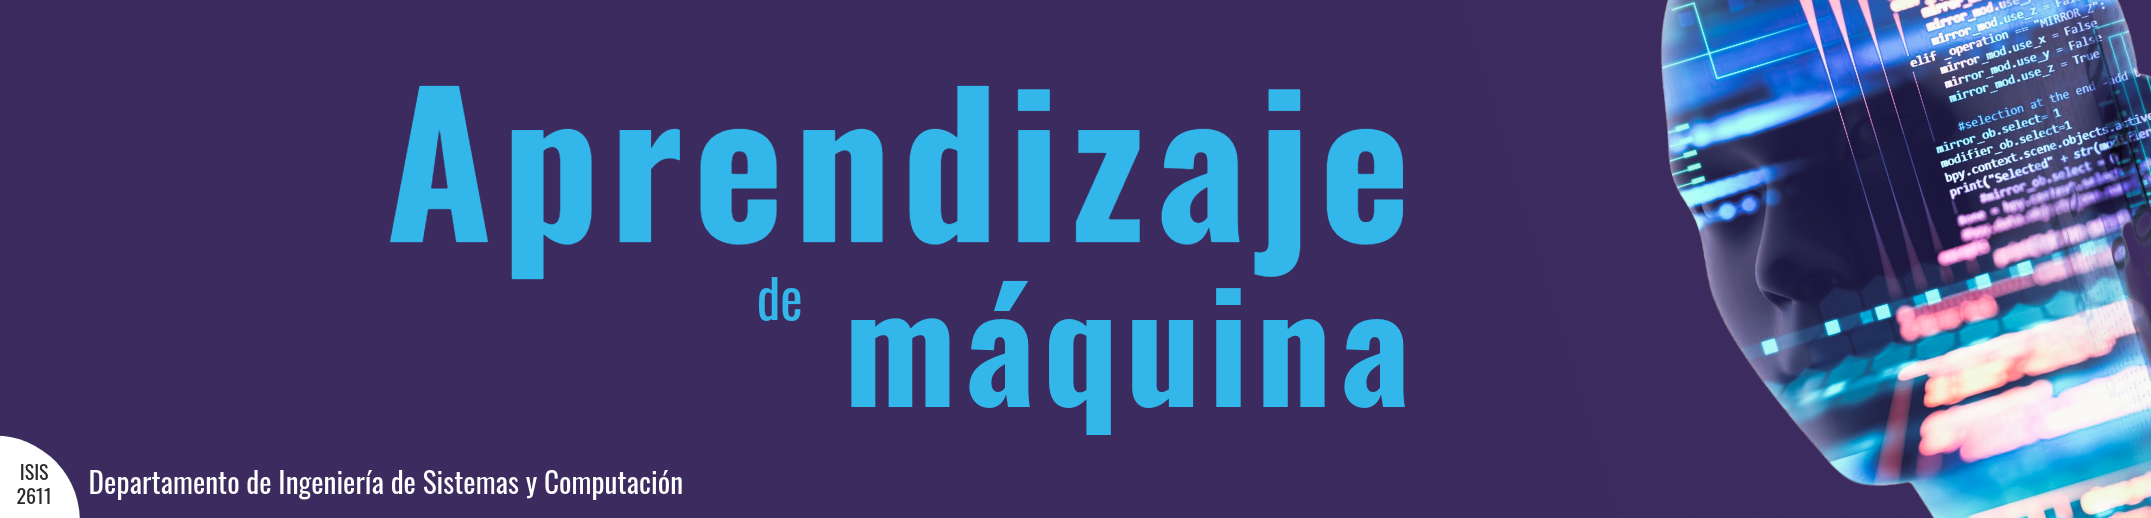

# Laboratorio 3 — Clasificación: SmartAlpes

En este laboratorio abordaremos la tarea de clasificación multiclase aplicada a un caso real de personalización deportiva. A diferencia de los ejercicios anteriores, donde se buscaba predecir un valor numérico, el objetivo aquí es asignar a cada cliente una categoría de plan de entrenamiento y una categoría de plan de nutrición, según su perfil físico, sus hábitos y su estilo de vida.

Para ello se construirán dos modelos independientes de Regresión Logística y dos modelos basados en Árboles de Decisión, uno por cada variable objetivo. Cada modelo se integrará en un pipeline reproducible que encadena el preprocesamiento y el estimador, y se realizará una búsqueda sistemática de hiperparámetros mediante validación cruzada. Finalmente, se compararán los modelos y se generarán predicciones sobre el conjunto de datos no etiquetado.

Este notebook está organizado en las siguientes secciones:

1. Importación de librerías
2. Carga de los datos
3. Exploración de los datos
4. Limpieza y preparación inicial de los datos
5. Partición de los datos
6. Construcción del pipeline
7. Modelo de Regresión Logística — Plan de entrenamiento
8. Modelo de Regresión Logística — Plan de nutrición
9. Modelo de Árbol de Decisión — Plan de entrenamiento
10. Modelo de Árbol de Decisión — Plan de nutrición
11. Tabla comparativa y selección del mejor modelo
12. Identificación de variables más relevantes
13. Predicciones sobre datos de prueba
14. Análisis de resultados
15. Conclusiones
16. Uso de IA generativa

## 1. Importación de librerías

En esta sección se cargan todas las librerías necesarias para el desarrollo del laboratorio. Se incluyen herramientas para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`), persistencia de modelos (`joblib`) y el ecosistema completo de `scikit-learn` para preprocesamiento, construcción de pipelines, búsqueda de hiperparámetros y evaluación de modelos de clasificación.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import (StandardScaler, RobustScaler, MinMaxScaler,
                                   OneHotEncoder, FunctionTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

## 2. Carga de los datos

En esta sección se cargan los datos de entrenamiento proporcionados por SmartAlpes. El archivo está separado por punto y coma (`;`) y contiene caracteres especiales propios del español, por lo que se especifica el parámetro `encoding='latin-1'` para evitar errores de lectura. Se trabaja sobre una copia del dataframe original con el fin de preservar los datos crudos ante cualquier transformación posterior.

In [10]:
data_smart = pd.read_csv('./data/Datos_Laboratorio3.csv', sep=';', encoding='latin-1')
data = data_smart.copy()

El diccionario de los datos es el siguiente:

| Variable | Tipo_variable | Descripción | Unidad | Valores / Rango sugerido |
|----------|--------------|-------------|--------|--------------------------|
| Edad | Numérica | Edad de la persona en años. | Años | Mayor que 0 |
| Gnereo | Categórica | Género de la persona. | — | Femenino, Masculino, Otro |
| Peso | Numérica | Peso corporal de la persona. | kg | Mayor que 0 |
| Altura | Numérica | Altura de la persona. | m | Mayor que 0 |
| BMI | Numérica | Índice de masa corporal calculado a partir del peso y la altura. | kg/m² | Mayor que 0 |
| Objetivo | Categórica | Objetivo principal de fitness de la persona. | — | Ganancia muscular, General, Perdida grasa, Resistencia |
| Condicion_salud | Categórica | Condiciones de salud relevantes que pueden influir en el plan. | — | Asma, Diabetes, Enfermedad corazon, Hipertension, Lesion, Ninguno, PCOS |
| Nivel_Actividad | Categórica | Nivel actual de actividad física habitual del usuario. | — | Alto, Bajo, Moderado |
| Nivel_experiencia | Categórica | Experiencia previa en entrenamiento o ejercicio físico. | — | Avanzado, Intermedio, Principiante |
| Dieta_preferida | Categórica | Preferencia alimentaria general. | — | No-Vegetariano, Pescetariano, Vegano, Vegetariano |
| Horas_sueño | Numérica | Número promedio de horas de sueño por día. | Horas | Mayor que 0 |
| Entrenamiento_preferido | Categórica | Tipo de entrenamiento que la persona prefiere realizar. | — | Balance, Cardio, Flexibilidad, Fuerza, Funcional, Hit |
| Cantidad_equipo | Numérica | Cantidad de equipo de entrenamiento disponible. | Conteo | Mayor o igual a 0 |
| Tiempo_disponible | Numérica | Tiempo disponible para entrenar. | Horas | Mayor que 0 |
| Tiene_alergia | Numérica | Indica si la persona presenta alergias alimentarias. | Binaria | 0 = No, 1 = Sí |
| Problemas_digestivos | Numérica | Indica si la persona tiene problemas digestivos. | Binaria | 0 = No, 1 = Sí |
| Fumador | Numérica | Indica si la persona fuma. | Binaria | 0 = No, 1 = Sí |
| Cigarrillos_dia | Numérica | Número aproximado de cigarrillos consumidos por día. | Conteo | Mayor o igual a 0 |
| Alcohol | Numérica | Indica si la persona consume alcohol. | Binaria | 0 = No, 1 = Sí |
| Alcohol_semana | Numérica | Cantidad aproximada de consumo de alcohol por semana. | Conteo | Mayor o igual a 0 |
| Score_micronutrientes | Numérica | Indicador estimado del consumo de micronutrientes en la dieta. | Índice | Mayor o igual a 0 |
| Ingesta_proteinas | Numérica | Nivel estimado de consumo de proteínas en la dieta. | g | Mayor o igual a 0 |
| Pasos_dia | Numérica | Número promedio de pasos caminados por día. | Conteo | Mayor o igual a 0 |
| Ingesta_agua | Numérica | Cantidad promedio de agua consumida por día. | Litros | Mayor o igual a 0 |
| Plan_entrenamiento | Categórica | Plan de entrenamiento recomendado para la persona. | — | Alto, Bajo, Medio, Ninguno |
| Plan_nutrición | Categórica | Plan nutricional recomendado para la persona. | — | Sin plan, Básico, Balanceado, Especializado |

## 3. Exploración del conjunto de datos

En esta sección se realiza una inspección inicial del conjunto de datos con el fin de comprender su estructura, distribución y posibles problemas de calidad. Se revisan las primeras filas, las dimensiones del dataframe, las estadísticas descriptivas de las variables numéricas y la distribución de las variables categóricas, incluyendo los targets `Plan_entrenamiento` y `Plan_nutrición`.

In [11]:
data.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [12]:
print(f"El dataset contiene {data.shape[0]} registros y {data.shape[1]} columnas.")

El dataset contiene 9698 registros y 26 columnas.


In [13]:
data.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


In [14]:
categoricas = data.select_dtypes(include='object').columns.tolist()
for col in categoricas:
    print(f"\n--- {col} ---")
    print(data[col].value_counts())


--- Gnereo ---
Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

--- Objetivo ---
Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

--- Condicion_salud ---
Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

--- Nivel_Actividad ---
Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64

--- Nivel_experiencia ---
Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

--- Dieta_preferida ---
Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64

--- Entrenamiento_prefe

In [15]:
print(data.nunique().sort_values())

Alcohol                       2
Fumador                       2
Problemas_digestivos          2
Tiene_alergia                 2
Gnereo                        3
Nivel_Actividad               3
Nivel_experiencia             3
Plan_nutrición                4
Plan_entrenamiento            4
Objetivo                      5
Dieta_preferida               5
Entrenamiento_preferido       6
Cantidad_equipo               7
Condicion_salud               7
Horas_sueño                  55
Altura                       56
Edad                         61
Score_micronutrientes       101
Tiempo_disponible           106
Cigarrillos_dia             172
Alcohol_semana              242
Ingesta_agua                351
Peso                        951
Ingesta_proteinas          1795
BMI                        3635
Pasos_dia                  7307
dtype: int64


La exploración inicial revela que el dataset contiene 9.698 registros y 26 columnas, de las cuales 24 corresponden a variables predictoras y 2 a las variables objetivo (`Plan_entrenamiento` y `Plan_nutrición`). Se observa que `Peso` presenta 11 valores ausentes (9.698 vs 9.687 en `count`), lo cual deberá tratarse en la etapa de limpieza mediante imputación.

Respecto a las variables categóricas, se identifican dos problemas de calidad relevantes. En la variable `Objetivo` aparece la categoría `grasa` con apenas 4 registros, la cual parece ser una variante mal escrita de `Perdida grasa`; este valor deberá unificarse en la etapa de limpieza. Adicionalmente, la columna `Gnereo` presenta un typo en su nombre (debería ser `Genero`), aunque dado que el nombre proviene del archivo original, se conservará tal cual para no alterar la lectura del CSV.

En cuanto a los targets, `Plan_entrenamiento` presenta desbalance de clases: `Ninguno` concentra el 39% de los registros, mientras que `Alto` representa apenas el 7%. De forma similar, `Plan_nutrición` muestra que `Balanceado` es la clase dominante con el 44%, mientras `Especializado` representa solo el 6%. Este desbalance deberá tenerse en cuenta durante el modelado, considerando el uso de `StratifiedKFold` en la validación cruzada y el análisis de métricas por clase en la evaluación.

## 4. Limpieza y preparación inicial de los datos

En esta sección se identifican y corrigen los problemas de calidad detectados durante la exploración. Se verifican ausencias, duplicados y valores inconsistentes en variables categóricas. Las correcciones que dependen del conjunto de entrenamiento (como la imputación) se delegan al pipeline, mientras que aquellas que son correcciones estructurales del dato se aplican directamente sobre el dataframe.


Verificación de ausencias:


In [16]:
data.isna().sum()

Edad                        0
Gnereo                      0
Peso                       11
Altura                      0
BMI                         0
Objetivo                    0
Condicion_salud             0
Nivel_Actividad             0
Nivel_experiencia           0
Dieta_preferida             0
Horas_sueño                 0
Entrenamiento_preferido     0
Cantidad_equipo             0
Tiempo_disponible           0
Tiene_alergia               0
Problemas_digestivos        0
Fumador                     0
Cigarrillos_dia             0
Alcohol                     0
Alcohol_semana              0
Score_micronutrientes       0
Ingesta_proteinas           0
Pasos_dia                   0
Ingesta_agua                0
Plan_entrenamiento          0
Plan_nutrición              0
dtype: int64


Verificación de duplicados:


In [17]:
print(f"Registros duplicados: {data.duplicated().sum()}")

Registros duplicados: 0


In [18]:
data['Objetivo'] = data['Objetivo'].replace('grasa', 'Perdida grasa')
print(data['Objetivo'].value_counts())

Objetivo
Ganancia muscular    2757
Perdida grasa        2598
General              2220
Resistencia          2123
Name: count, dtype: int64


La verificación de ausencias confirma que únicamente la variable `Peso` presenta 11 valores faltantes, lo que representa menos del 0.2% del total de registros. Dado que esta proporción es muy baja, se optará por imputación con la media dentro del pipeline, evitando así la pérdida de información. No se detectaron registros duplicados, por lo que no es necesaria ninguna eliminación de filas.

Respecto a la corrección categórica, la categoría `grasa` detectada en la exploración fue unificada exitosamente con `Perdida grasa`, pasando de 2.594 a 2.598 registros en dicha clase. Con esta corrección, la variable `Objetivo` queda con exactamente 4 categorías bien definidas: `Ganancia muscular`, `Perdida grasa`, `General` y `Resistencia`. El dataset queda listo para la partición y el modelado, con todas las variables en un estado consistente.

## 5. Partición de los datos

En esta sección se separan las variables predictoras de las variables objetivo y se dividen los datos en conjuntos de entrenamiento (80%) y prueba (20%). Dado que el laboratorio requiere dos modelos independientes, se definen dos variables objetivo: `Plan_entrenamiento` y `Plan_nutrición`. La partición se realiza con `random_state=1` para garantizar reproducibilidad y con `stratify=y` para preservar la proporción de clases en ambos conjuntos, lo cual es especialmente importante dado el desbalance observado en la exploración.

In [19]:
X = data.drop(columns=['Plan_entrenamiento', 'Plan_nutrición'])
y_ent = data['Plan_entrenamiento']
y_nut = data['Plan_nutrición']

In [20]:
X_train_ent, X_test_ent, y_train_ent, y_test_ent = train_test_split(
    X, y_ent, test_size=0.2, random_state=1, stratify=y_ent
)
print(f"Entrenamiento — Plan_entrenamiento: {X_train_ent.shape}, {X_test_ent.shape}")

Entrenamiento — Plan_entrenamiento: (7758, 24), (1940, 24)


In [21]:
X_train_nut, X_test_nut, y_train_nut, y_test_nut = train_test_split(
    X, y_nut, test_size=0.2, random_state=1, stratify=y_nut
)
print(f"Entrenamiento — Plan_nutrición: {X_train_nut.shape}, {X_test_nut.shape}")

Entrenamiento — Plan_nutrición: (7758, 24), (1940, 24)


La partición resultó en 7.758 registros para entrenamiento y 1.940 para prueba, correspondiendo exactamente al 80% y 20% del total respectivamente. Ambos targets comparten el mismo `X`, por lo que las dimensiones son idénticas en los dos casos: 24 variables predictoras, que incluyen todas las columnas del dataset excepto las dos variables objetivo. El uso de `stratify=y` garantiza que la proporción de cada clase se mantenga en ambos conjuntos, lo cual es fundamental dado el desbalance observado en `Plan_entrenamiento` (donde `Alto` representa apenas el 7% de los datos) y en `Plan_nutrición` (donde `Especializado` representa el 6%).

## 6. Construcción del pipeline

En esta sección se construye el pipeline base que será compartido por todos los modelos del laboratorio. El pipeline encadena de forma ordenada todas las transformaciones necesarias, garantizando que exactamente los mismos pasos se apliquen tanto al conjunto de entrenamiento como al de prueba o a nuevos datos en producción.

El primer paso consiste en eliminar las columnas que no aportan información predictiva o que podrían introducir fuga de información. Por defecto no se elimina ninguna columna adicional, ya que los dos targets fueron separados previamente en la partición. Esta función se define de forma flexible para poder agregar columnas en caso de que el análisis lo justifique.

In [22]:
cols_to_drop = ['BMI']  # Se puede agregar 'BMI' aquí si se decide excluirla

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore')

dropper = FunctionTransformer(drop_columns)

El segundo paso corrige valores que no deberían ser negativos desde la perspectiva del dominio. Variables como `Peso`, `Altura`, `Horas_sueño`, `Pasos_dia` e `Ingesta_agua` no admiten valores negativos, por lo que se reemplazan por `NaN` para que el imputador los trate en el paso siguiente.

In [23]:
vars_no_negativas = ['Edad', 'Peso', 'Altura', 'Horas_sueño',
                     'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia',
                     'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas',
                     'Pasos_dia', 'Ingesta_agua']

def limpieza_clinica(df):
    df = df.copy()
    for col in vars_no_negativas:
        if col in df.columns:
            df[col] = df[col].where(df[col] >= 0, other=np.nan)
    return df

limpiador = FunctionTransformer(limpieza_clinica)

El tercer paso unifica el formato de las variables categóricas, convirtiendo todos los valores a minúsculas y eliminando espacios innecesarios. Esto evita que variantes como `"Vegano"` y `"vegano"` sean tratadas como categorías distintas por el codificador.

In [24]:
def normalizar_categoricas(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower()
    return df

normalizador = FunctionTransformer(normalizar_categoricas)

Se separan explícitamente las variables numéricas y categóricas para aplicar transformaciones diferenciadas en el `ColumnTransformer`.

In [25]:
numericas_features = ['Edad', 'Peso', 'Altura', 'Horas_sueño',
                      'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia',
                      'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia',
                      'Alcohol', 'Alcohol_semana', 'Score_micronutrientes',
                      'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']

categoricas_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
                        'Nivel_experiencia', 'Dieta_preferida',
                        'Entrenamiento_preferido']

Se define el `ColumnTransformer` con una rama numérica y una rama categórica. La rama numérica aplica imputación por media seguida de escalado; la rama categórica aplica imputación por moda seguida de codificación one-hot. El escalador se deja como parámetro para explorarlo mediante `GridSearchCV`.

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as PipelineStep

rama_numerica = PipelineStep(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

rama_categorica = PipelineStep(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocesador = ColumnTransformer(transformers=[
    ('num', rama_numerica, numericas_features),
    ('cat', rama_categorica, categoricas_features)
])

Finalmente se ensambla el pipeline completo con los cinco pasos en orden: `dropper`, `limpieza_clinica`, `normalizar_categoricas_tr`, `preprocesamiento` y `modelo`. El modelo se deja como `LogisticRegression` con `max_iter=1000` para garantizar convergencia en problemas multiclase.

In [27]:
pipeline_rl = Pipeline(steps=[
    ('dropper', dropper),
    ('limpieza_clinica', limpiador),
    ('normalizar_categoricas_tr', normalizador),
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

print(pipeline_rl)

Pipeline(steps=[('dropper',
                 FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                ('limpieza_clinica',
                 FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                ('normalizar_categoricas_tr',
                 FunctionTransformer(func=<function normalizar_categoricas at 0x128a42ca0>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(ste...
                                                   'Ingesta_proteinas',
                                                   'Pasos_dia',
                                                   'Ingesta_agua']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
              

El pipeline quedó correctamente ensamblado con cinco etapas en el orden establecido. El paso `dropper` elimina columnas irrelevantes, `limpieza_clinica` reemplaza valores negativos por `NaN`, y `normalizar_categoricas_tr` unifica el formato de texto en variables categóricas. El `preprocesamiento` aplica de forma diferenciada las transformaciones según el tipo de variable: imputación por media y escalado para las 17 variables numéricas, e imputación por moda y codificación one-hot para las 7 variables categóricas. Finalmente, el paso `modelo` contiene la `LogisticRegression` con `max_iter=1000` para garantizar la convergencia en el problema multiclase. Este pipeline base será reutilizado para ambos targets ajustando únicamente los hiperparámetros del modelo mediante `GridSearchCV`.

## 7. Modelo de Regresión Logística — Plan de entrenamiento

La regresión logística es un modelo ampliamente utilizado en clasificación que estima la probabilidad de pertenencia a una clase mediante una función logística. En su versión multiclase, scikit-learn extiende este enfoque mediante la estrategia `multinomial` o `ovr` (one-vs-rest), según el solver utilizado. Su desempeño puede ajustarse mediante hiperparámetros como el tipo de regularización (`penalty`), la fuerza de regularización (`C`) y el escalador aplicado en el preprocesamiento. Se construye un modelo independiente para cada variable objetivo, comenzando por `Plan_entrenamiento`.

Se define el espacio de búsqueda explorando las combinaciones válidas de penalización, solver y escalador. Se incluyen los tres escaladores exigidos por la metodología (`StandardScaler`, `RobustScaler`, `MinMaxScaler`) como parte del grid, lo que permite identificar cuál representación del espacio de features favorece más al modelo.

In [28]:
param_grid_rl = [
    {
        'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
        'modelo__penalty': ['l2'],
        'modelo__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'modelo__C': [0.1, 0.5, 1, 5, 10]
    },
    {
        'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear'],
        'modelo__C': [0.1, 0.5, 1, 5, 10]
    }
]

Se utiliza `StratifiedKFold` con 5 particiones en lugar de `KFold`, ya que el problema es de clasificación multiclase con clases desbalanceadas. La versión estratificada garantiza que cada fold mantenga la misma proporción de clases que el conjunto completo, evitando que algún fold quede sin representación de la clase minoritaria.

In [29]:
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

Se realiza la búsqueda exhaustiva de hiperparámetros con `GridSearchCV`, usando `f1_macro` como métrica de optimización. A diferencia del F1 binario, `f1_macro` calcula el F1 de cada clase de forma independiente y promedia los resultados dando el mismo peso a todas las clases, lo que es adecuado para problemas multiclase con desbalance. Se activa `return_train_score=True` para poder diagnosticar sobreajuste.

In [30]:
grid_rl_ent = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=skfold,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_rl_ent.fit(X_train_ent, y_train_ent)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                                       ('limpieza_clinica',
                                        FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                                       ('normalizar_categoricas_tr',
                                        FunctionTransformer(func=<function normalizar_categoricas at 0x12...
                          'modelo__penalty': ['l2'],
                          'modelo__solver': ['newton-cg', 'lbfgs', 'liblinear'],
                          'preprocesamiento__num__scaler': [StandardScaler(),
                                                            RobustScaler(),
                                                            MinMaxScaler()]},
                         {'modelo__C': [0.1, 0.5, 1, 5, 10],
                          'modelo__penalty': ['l1'],
                          'modelo__solver': ['liblinear'],
                          'preprocesamiento__num__scaler': [StandardScaler(),
                                                            RobustScaler(),
                                                            MinMaxScaler()]}],
             return_train_score=True, scoring='f1_macro')

In [31]:
print("Mejores hiperparámetros:", grid_rl_ent.best_params_)
print("Mejor F1-macro en CV:", round(grid_rl_ent.best_score_, 4))

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'newton-cg', 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor F1-macro en CV: 0.8865


In [32]:
resultados_rl_ent = pd.DataFrame(grid_rl_ent.cv_results_)
cols = [
    'param_preprocesamiento__num__scaler',
    'param_modelo__penalty',
    'param_modelo__solver',
    'param_modelo__C',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary_rl_ent = resultados_rl_ent[cols].sort_values(by='rank_test_score').head(10)
print(summary_rl_ent.to_string())

   param_preprocesamiento__num__scaler param_modelo__penalty param_modelo__solver  param_modelo__C  mean_train_score  mean_test_score  std_test_score  rank_test_score
38                      MinMaxScaler()                    l2            newton-cg             10.0          0.899157         0.886499        0.013021                1
27                    StandardScaler()                    l2            newton-cg              5.0          0.898952         0.886496        0.013668                2
40                      RobustScaler()                    l2                lbfgs             10.0          0.899267         0.885922        0.013098                3
41                      MinMaxScaler()                    l2                lbfgs             10.0          0.898916         0.885841        0.014291                4
32                      MinMaxScaler()                    l2                lbfgs              5.0          0.897132         0.885532        0.011925                

In [33]:
best_model_rl_ent = grid_rl_ent.best_estimator_

La búsqueda de hiperparámetros evaluó combinaciones de penalización, solver y escalador sobre 5 folds estratificados. El mejor modelo obtuvo un F1-macro de 0.8865 en validación cruzada, con los hiperparámetros `penalty='l2'`, `solver='newton-cg'`, `C=10` y `MinMaxScaler()` como escalador. La penalización L2 dominó completamente el top 10, lo que sugiere que la regularización ridge es más adecuada que L1 para este problema, posiblemente porque la mayoría de las variables aportan información y no conviene llevar coeficientes a cero.

La diferencia entre el `mean_train_score` (≈0.899) y el `mean_test_score` (≈0.886) es pequeña y consistente en todas las combinaciones del top 10, lo que indica que el modelo generaliza bien sin signos evidentes de sobreajuste. Los valores de `std_test_score` se mantienen bajos (≈0.013), reflejando estabilidad en las predicciones a través de los folds. Respecto al escalador, `MinMaxScaler` y `StandardScaler` obtuvieron resultados muy similares, con diferencias menores a 0.002, lo que indica que la regresión logística con regularización L2 no es especialmente sensible al tipo de escalado en este dataset.

## 8. Evaluación del mejor modelo — Regresión Logística Plan de entrenamiento

Con el mejor estimador identificado por `GridSearchCV`, se generan las predicciones sobre el conjunto de prueba. Gracias al parámetro `refit=True` (valor por defecto), el modelo fue reentrenado automáticamente con la mejor combinación de hiperparámetros usando todo el conjunto de entrenamiento, por lo que `best_estimator_` está listo para predecir sobre nuevos datos.

In [34]:
y_pred_rl_ent = best_model_rl_ent.predict(X_test_ent)

In [35]:
print(classification_report(y_test_ent, y_pred_rl_ent))

              precision    recall  f1-score   support

        Alto       0.93      0.82      0.87       131
        Bajo       0.80      0.77      0.78       458
       Medio       0.89      0.90      0.89       589
     Ninguno       0.92      0.95      0.94       762

    accuracy                           0.88      1940
   macro avg       0.88      0.86      0.87      1940
weighted avg       0.88      0.88      0.88      1940



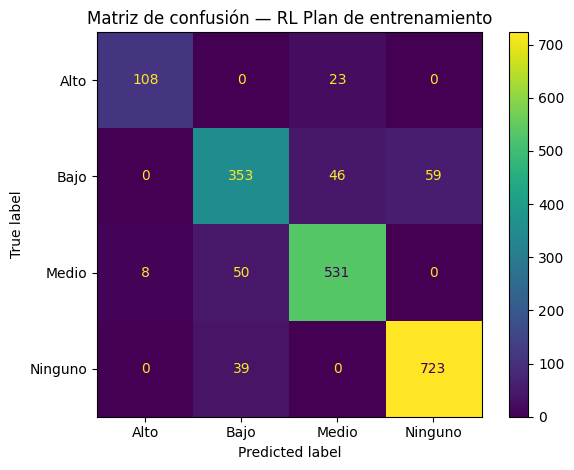

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test_ent, y_pred_rl_ent)
plt.title("Matriz de confusión — RL Plan de entrenamiento")
plt.tight_layout()
plt.show()

Para interpretar el modelo, se extraen los coeficientes de la regresión logística. En problemas multiclase, el modelo aprende un vector de coeficientes por cada clase, por lo que se visualizan las variables más influyentes para cada una de las cuatro categorías de `Plan_entrenamiento`.

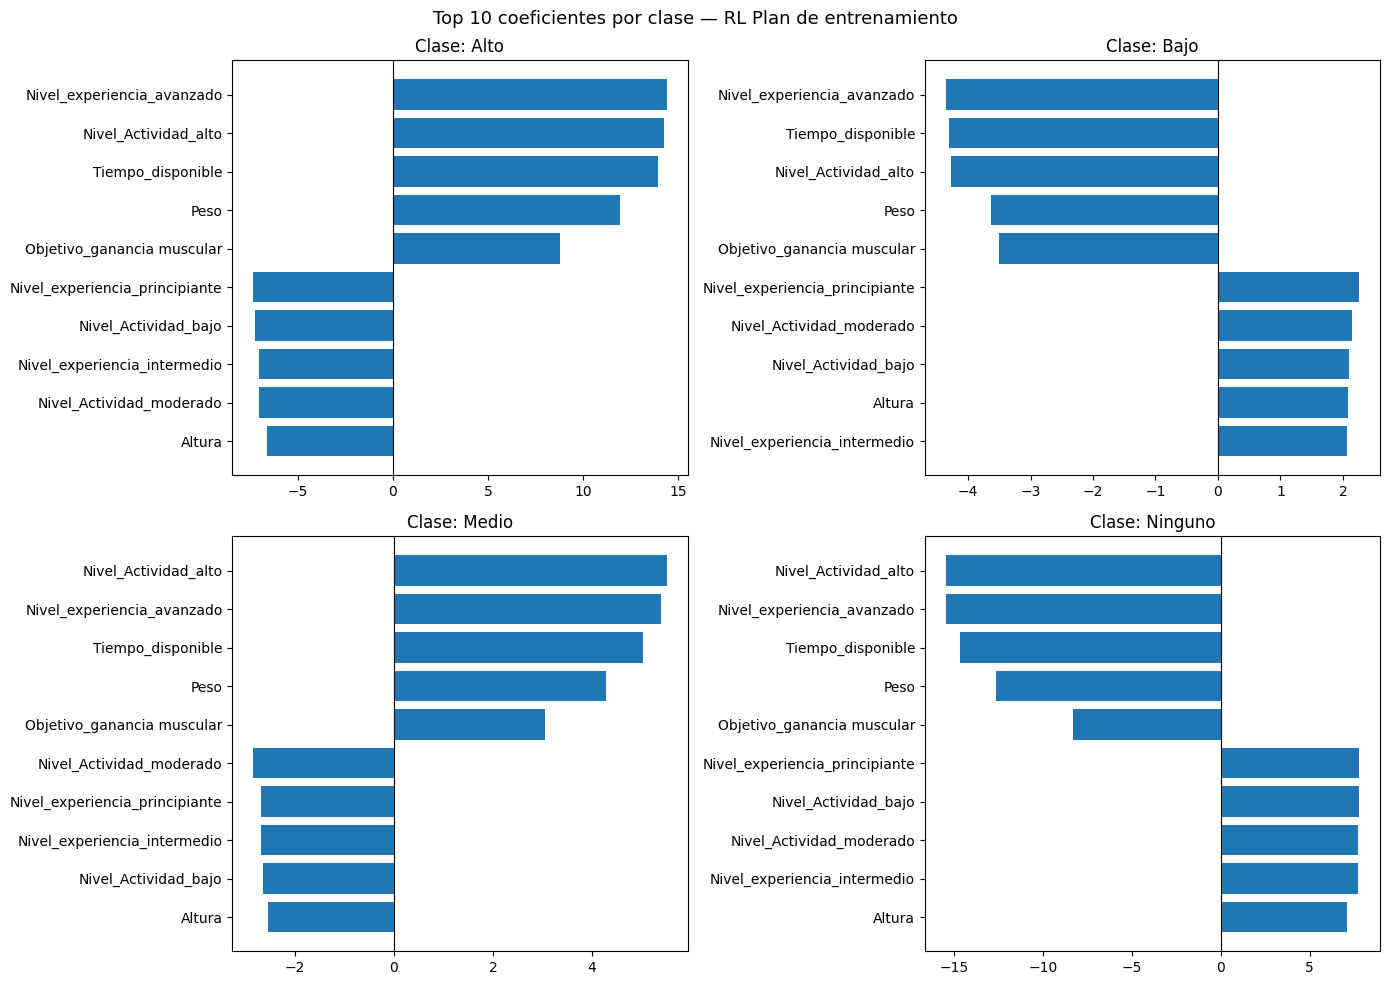

In [37]:
preprocesador_fit = best_model_rl_ent.named_steps['preprocesamiento']
log_reg_fit = best_model_rl_ent.named_steps['modelo']

# Nombres de features
feature_names_num = numericas_features
ohe = preprocesador_fit.transformers_[1][1].named_steps['onehot']
feature_names_cat = ohe.get_feature_names_out(categoricas_features)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

# Coeficientes por clase
clases = log_reg_fit.classes_
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, clase in enumerate(clases):
    coefs = log_reg_fit.coef_[i]
    coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})
    coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(10)
    axes[i].barh(coef_df['feature'], coef_df['coef'])
    axes[i].set_title(f'Clase: {clase}')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].invert_yaxis()

plt.suptitle('Top 10 coeficientes por clase — RL Plan de entrenamiento', fontsize=13)
plt.tight_layout()
plt.show()

El modelo de regresión logística alcanza una exactitud del 88% sobre el conjunto de prueba, con un F1-macro de 0.87, lo que refleja un desempeño sólido considerando que el problema tiene cuatro clases con distribución desbalanceada. La clase `Ninguno` obtiene las mejores métricas (F1 = 0.94), lo cual es consistente con su mayor representación en el dataset. La clase `Bajo` presenta el desempeño más débil (F1 = 0.78), con un recall de 0.77 que indica que aproximadamente uno de cada cuatro casos de esta clase no es correctamente identificado.

La matriz de confusión revela que los errores más frecuentes ocurren entre clases adyacentes en intensidad: `Bajo` se confunde con `Medio` (46 casos) y con `Ninguno` (59 casos), mientras que `Medio` se confunde con `Bajo` (50 casos). Esto sugiere que el modelo tiene dificultades para distinguir entre niveles intermedios de actividad, lo cual es esperable dado que los perfiles de clientes en estas categorías pueden ser similares en varias variables predictoras. La clase `Alto` presenta 23 casos mal clasificados como `Medio`, lo que indica que algunos clientes con perfil de entrenamiento alto son subestimados por el modelo.

Respecto a los coeficientes, las variables `Nivel_experiencia_avanzado`, `Nivel_Actividad_alto` y `Tiempo_disponible` son los predictores más influyentes para la clase `Alto`, con coeficientes positivos superiores a 13. En contraste, para la clase `Ninguno`, estas mismas variables presentan coeficientes negativos muy grandes (entre -10 y -15), confirmando que un alto nivel de experiencia y actividad reduce fuertemente la probabilidad de no recibir plan. La variable `Peso` aparece con efecto positivo en `Alto` y `Medio`, pero negativo en `Ninguno`, lo que podría reflejar que clientes con mayor peso tienden a recibir planes más intensivos. En general, el modelo concentra su poder discriminativo en variables de perfil deportivo (`Nivel_experiencia`, `Nivel_Actividad`) y de disponibilidad (`Tiempo_disponible`), mientras que variables como `Altura` aparecen con efectos negativos moderados en varias clases.

## 9. Modelo de Regresión Logística — Plan de nutrición

En esta sección se construye el segundo modelo de regresión logística, ahora orientado a predecir la variable `Plan_nutrición`. Se reutiliza el mismo pipeline base y el mismo espacio de hiperparámetros definidos anteriormente, garantizando comparabilidad entre ambos modelos. La búsqueda se realiza nuevamente con `StratifiedKFold` y `f1_macro` como métrica de optimización.

In [38]:
grid_rl_nut = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=skfold,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_rl_nut.fit(X_train_nut, y_train_nut)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                                       ('limpieza_clinica',
                                        FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                                       ('normalizar_categoricas_tr',
                                        FunctionTransformer(func=<function normalizar_categoricas at 0x12...
                          'modelo__penalty': ['l2'],
                          'modelo__solver': ['newton-cg', 'lbfgs', 'liblinear'],
                          'preprocesamiento__num__scaler': [StandardScaler(),
                                                            RobustScaler(),
                                                            MinMaxScaler()]},
                         {'modelo__C': [0.1, 0.5, 1, 5, 10],
                          'modelo__penalty': ['l1'],
                          'modelo__solver': ['liblinear'],
                          'preprocesamiento__num__scaler': [StandardScaler(),
                                                            RobustScaler(),
                                                            MinMaxScaler()]}],
             return_train_score=True, scoring='f1_macro')

In [39]:
print("Mejores hiperparámetros:", grid_rl_nut.best_params_)
print("Mejor F1-macro en CV:", round(grid_rl_nut.best_score_, 4))

Mejores hiperparámetros: {'modelo__C': 5, 'modelo__penalty': 'l2', 'modelo__solver': 'newton-cg', 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor F1-macro en CV: 0.7886


In [40]:
resultados_rl_nut = pd.DataFrame(grid_rl_nut.cv_results_)
cols = [
    'param_preprocesamiento__num__scaler',
    'param_modelo__penalty',
    'param_modelo__solver',
    'param_modelo__C',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary_rl_nut = resultados_rl_nut[cols].sort_values(by='rank_test_score').head(10)
print(summary_rl_nut.to_string())

   param_preprocesamiento__num__scaler param_modelo__penalty param_modelo__solver  param_modelo__C  mean_train_score  mean_test_score  std_test_score  rank_test_score
29                      MinMaxScaler()                    l2            newton-cg              5.0          0.797954         0.788625        0.008280                1
31                      RobustScaler()                    l2                lbfgs              5.0          0.799099         0.788193        0.008890                2
30                    StandardScaler()                    l2                lbfgs              5.0          0.799233         0.788155        0.008852                3
28                      RobustScaler()                    l2            newton-cg              5.0          0.798870         0.788118        0.009158                4
40                      RobustScaler()                    l2                lbfgs             10.0          0.799904         0.788069        0.009026                

In [41]:
best_model_rl_nut = grid_rl_nut.best_estimator_

In [42]:
y_pred_rl_nut = best_model_rl_nut.predict(X_test_nut)
print(classification_report(y_test_nut, y_pred_rl_nut))

               precision    recall  f1-score   support

   Balanceado       0.84      0.88      0.86       860
       Basico       0.70      0.66      0.68       457
Especializado       0.70      0.57      0.63       118
     Sin plan       0.88      0.89      0.89       505

     accuracy                           0.81      1940
    macro avg       0.78      0.75      0.76      1940
 weighted avg       0.81      0.81      0.81      1940



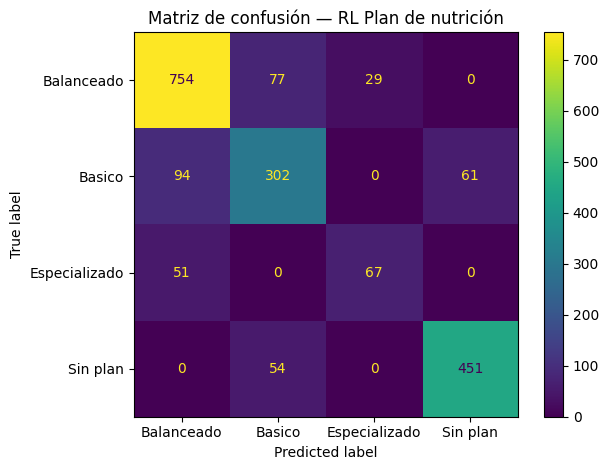

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test_nut, y_pred_rl_nut)
plt.title("Matriz de confusión — RL Plan de nutrición")
plt.tight_layout()
plt.show()

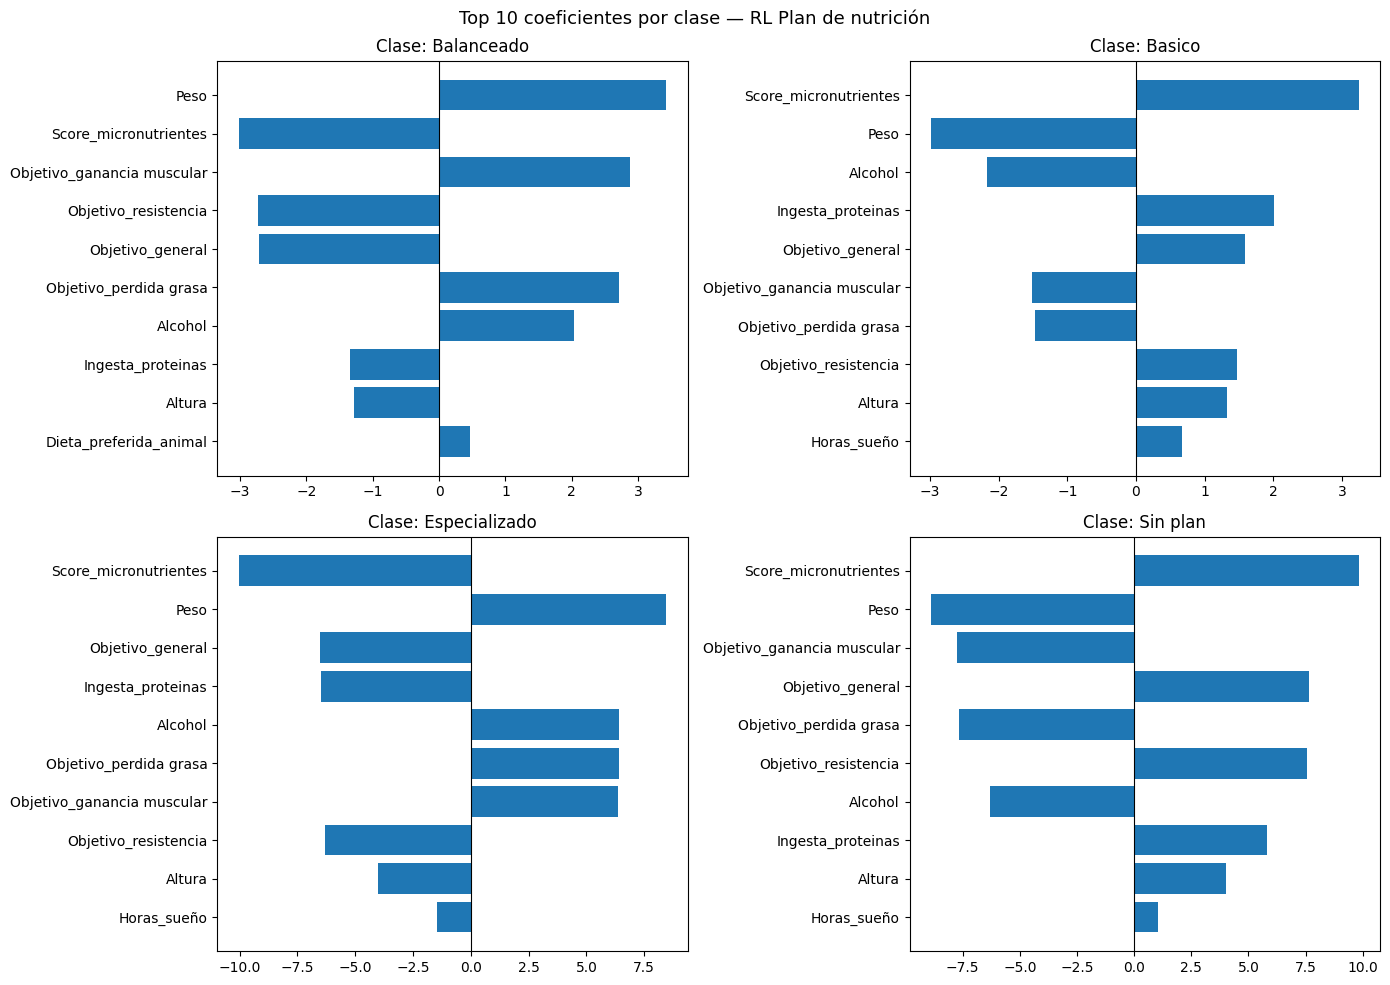

In [44]:
preprocesador_fit_nut = best_model_rl_nut.named_steps['preprocesamiento']
log_reg_fit_nut = best_model_rl_nut.named_steps['modelo']

ohe_nut = preprocesador_fit_nut.transformers_[1][1].named_steps['onehot']
feature_names_cat_nut = ohe_nut.get_feature_names_out(categoricas_features)
all_feature_names_nut = np.concatenate([numericas_features, feature_names_cat_nut])

clases_nut = log_reg_fit_nut.classes_
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, clase in enumerate(clases_nut):
    coefs = log_reg_fit_nut.coef_[i]
    coef_df = pd.DataFrame({'feature': all_feature_names_nut, 'coef': coefs})
    coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(10)
    axes[i].barh(coef_df['feature'], coef_df['coef'])
    axes[i].set_title(f'Clase: {clase}')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].invert_yaxis()

plt.suptitle('Top 10 coeficientes por clase — RL Plan de nutrición', fontsize=13)
plt.tight_layout()
plt.show()

El modelo de regresión logística para `Plan_nutrición` obtuvo un F1-macro de 0.7886 en validación cruzada, inferior al 0.8865 alcanzado para `Plan_entrenamiento`, lo que sugiere que la predicción del plan nutricional es una tarea más compleja para este algoritmo. La mejor configuración coincide parcialmente con el modelo anterior: `penalty='l2'`, `solver='newton-cg'` y `MinMaxScaler()`, aunque con `C=5` en lugar de `C=10`, indicando una regularización ligeramente más fuerte. Al igual que antes, la penalización L2 dominó el top 10 y las diferencias entre escaladores fueron mínimas, con variaciones menores a 0.002.

Sobre el conjunto de prueba, el modelo alcanza una exactitud del 81% y un F1-macro de 0.76. Las clases `Sin plan` y `Balanceado` presentan el mejor desempeño con F1 de 0.89 y 0.86 respectivamente, beneficiándose de su mayor representación en el dataset. En contraste, `Especializado` obtiene el F1 más bajo (0.63) con un recall de apenas 0.57, lo que indica que el modelo no logra identificar correctamente casi la mitad de los clientes que deberían recibir un plan especializado. La clase `Basico` también presenta dificultades con un F1 de 0.68.

La matriz de confusión revela que los errores más frecuentes ocurren entre `Balanceado` y `Basico` (77 casos mal clasificados como `Balanceado`) y entre `Especializado` y `Balanceado` (51 casos), lo que sugiere que el modelo tiende a asignar la clase mayoritaria cuando no tiene suficiente certeza. Respecto a los coeficientes, `Score_micronutrientes` y `Peso` son las variables más influyentes en casi todas las clases, con efectos opuestos según la categoría: `Score_micronutrientes` alto favorece `Balanceado` negativamente pero `Sin plan` positivamente, mientras que `Peso` alto se asocia con `Especializado`. El `Objetivo` del cliente también muestra un papel relevante, con `ganancia muscular` y `perdida grasa` influyendo en direcciones distintas según el plan nutricional evaluado.

## 10. Modelo de Árbol de Decisión — Plan de entrenamiento

Los árboles de decisión son modelos no paramétricos que aprenden reglas de clasificación jerárquicas a partir de los datos. A diferencia de la regresión logística, no requieren que las variables estén escaladas, ya que las particiones se basan en umbrales sobre los valores originales. Su principal ventaja es la interpretabilidad: cada camino desde la raíz hasta una hoja puede leerse como una regla de negocio explícita.

Para este modelo se reutiliza la misma estructura de preprocesamiento del pipeline anterior, con la diferencia de que **la rama numérica no aplica escalado** (se usa solo imputación), ya que los árboles son invariantes a la escala.

In [45]:
# Para árboles de decisión no se necesita escalado en variables numéricas
rama_numerica_dt = PipelineStep(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

rama_categorica_dt = PipelineStep(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocesador_dt = ColumnTransformer(transformers=[
    ('num', rama_numerica_dt, numericas_features),
    ('cat', rama_categorica_dt, categoricas_features)
])

pipeline_dt = Pipeline(steps=[
    ('dropper', dropper),
    ('limpieza_clinica', limpiador),
    ('normalizar_categoricas_tr', normalizador),
    ('preprocesamiento', preprocesador_dt),
    ('modelo', DecisionTreeClassifier(random_state=1))
])

print(pipeline_dt)

Pipeline(steps=[('dropper',
                 FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                ('limpieza_clinica',
                 FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                ('normalizar_categoricas_tr',
                 FunctionTransformer(func=<function normalizar_categoricas at 0x128a42ca0>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(ste...
                                                   'Pasos_dia',
                                                   'Ingesta_agua']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
         

### 10.1 Búsqueda de hiperparámetros — Plan de entrenamiento

Se exploran hiperparámetros divididos en dos grupos: los que controlan el **criterio de partición** (`criterion`, `max_features`) y los que regulan la **complejidad del árbol** (`max_depth`, `min_samples_split`, `min_samples_leaf`). Controlar la complejidad es fundamental para evitar sobreajuste, ya que un árbol sin restricciones puede memorizar el conjunto de entrenamiento.

Se utiliza `StratifiedKFold` con 5 particiones para mantener la proporción de clases en cada fold, y `f1_macro` como métrica de optimización para tratar todas las clases por igual.

In [46]:
param_grid_dt = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_features': ['sqrt', 'log2', None],
    'modelo__max_depth': [5, 10, 15, 20, None],
    'modelo__min_samples_split': [2, 10, 20],
    'modelo__min_samples_leaf': [1, 5, 10]
}

In [47]:
grid_dt_ent = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=skfold,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_dt_ent.fit(X_train_ent, y_train_ent)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                                       ('limpieza_clinica',
                                        FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                                       ('normalizar_categoricas_tr',
                                        FunctionTransformer(func=<function normalizar_categoricas at 0x12...
                                                                          'Dieta_preferida',
                                                                          'Entrenamiento_preferido'])])),
                                       ('modelo',
                                        DecisionTreeClassifier(random_state=1))]),
             n_jobs=-1,
             param_grid={'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [5, 10, 15, 20, None],
                         'modelo__max_features': ['sqrt', 'log2', None],
                         'modelo__min_samples_leaf': [1, 5, 10],
                         'modelo__min_samples_split': [2, 10, 20]},
             return_train_score=True, scoring='f1_macro')

In [48]:
print("Mejores hiperparámetros — Árbol Plan entrenamiento:")
display(grid_dt_ent.best_params_)
print(f"\nMejor F1-macro en CV: {grid_dt_ent.best_score_:.4f}")

Mejores hiperparámetros — Árbol Plan entrenamiento:


{'modelo__criterion': 'entropy',
 'modelo__max_depth': 15,
 'modelo__max_features': None,
 'modelo__min_samples_leaf': 1,
 'modelo__min_samples_split': 2}


Mejor F1-macro en CV: 0.9701


In [49]:
resultados_dt_ent = pd.DataFrame(grid_dt_ent.cv_results_)
cols_dt = [
    'param_modelo__criterion',
    'param_modelo__max_depth',
    'param_modelo__min_samples_split',
    'param_modelo__min_samples_leaf',
    'param_modelo__max_features',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary_dt_ent = resultados_dt_ent[cols_dt].sort_values('rank_test_score').head(10)
display(summary_dt_ent)

,param_modelo__criterion,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__min_samples_leaf,param_modelo__max_features,mean_test_score,std_test_score,rank_test_score
261,entropy,None,2,1,None,0.970124,0.001988,1
234,entropy,20,2,1,None,0.970124,0.001988,1
207,entropy,15,2,1,None,0.970124,0.001988,1
208,entropy,15,10,1,None,0.969767,0.004349,4
262,entropy,None,10,1,None,0.969767,0.004349,4
235,entropy,20,10,1,None,0.969767,0.004349,4
266,entropy,None,20,5,None,0.969395,0.004023,7
212,entropy,15,20,5,None,0.969395,0.004023,7
239,entropy,20,20,5,None,0.969395,0.004023,7
237,entropy,20,2,5,None,0.969340,0.002964,10


La búsqueda de hiperparámetros evaluó combinaciones de criterio de partición, profundidad máxima, mínimo de muestras por nodo y número de features consideradas en cada split. El mejor modelo obtuvo un **F1-macro de 0.9701 en validación cruzada**, resultado notablemente superior al 0.8865 alcanzado por la regresión logística para el mismo objetivo, lo que sugiere que el árbol de decisión captura relaciones no lineales en los datos que el modelo lineal no logra modelar.

La configuración ganadora utiliza **criterio de entropía**, **profundidad máxima de 15** y **`max_features=None`** (es decir, considera todas las variables en cada split), con los valores mínimos de restricción (`min_samples_split=2`, `min_samples_leaf=1`). Esto indica que el modelo se beneficia de una mayor libertad para construir particiones finas, sin necesidad de regularización agresiva en la estructura del árbol.

Un aspecto relevante del top 10 es que **la entropía domina por completo** como criterio de partición, sin ninguna aparición de Gini entre las mejores configuraciones. Esto sugiere que la entropía, al penalizar con mayor sensibilidad las distribuciones impuras, resulta más adecuada para capturar las fronteras de decisión de este problema. Adicionalmente, todas las configuraciones del top 10 utilizan `max_features=None`, lo que refuerza que incluir todas las variables en cada nodo es beneficioso dado el número moderado de features disponibles. Las diferencias de F1-macro entre las diez mejores configuraciones son menores a 0.001, lo que indica que el espacio de soluciones es estable en esa región.

### 10.2 Evaluación sobre el conjunto de prueba — Plan de entrenamiento

In [50]:
best_model_dt_ent = grid_dt_ent.best_estimator_
y_pred_dt_ent = best_model_dt_ent.predict(X_test_ent)

print("=== Reporte de clasificación — Árbol de Decisión: Plan de entrenamiento ===")
print(classification_report(y_test_ent, y_pred_dt_ent))

=== Reporte de clasificación — Árbol de Decisión: Plan de entrenamiento ===
              precision    recall  f1-score   support

        Alto       0.94      0.93      0.93       131
        Bajo       0.98      0.97      0.97       458
       Medio       0.97      0.98      0.98       589
     Ninguno       0.99      0.99      0.99       762

    accuracy                           0.98      1940
   macro avg       0.97      0.97      0.97      1940
weighted avg       0.98      0.98      0.98      1940



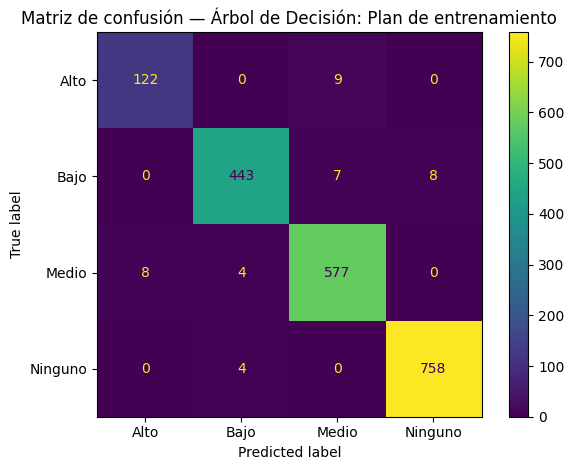

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test_ent, y_pred_dt_ent)
plt.title("Matriz de confusión — Árbol de Decisión: Plan de entrenamiento")
plt.tight_layout()
plt.show()

El árbol de decisión alcanza una **exactitud del 98%** sobre el conjunto de prueba, con un **F1-macro de 0.97**, superando ampliamente a la regresión logística que obtuvo 0.87 en el mismo objetivo. Este resultado confirma que el árbol captura de forma efectiva las reglas que determinan el plan de entrenamiento recomendado.

A nivel de clases, el desempeño es consistentemente alto en todas las categorías. `Ninguno` obtiene el mejor F1 (0.99), seguido de `Medio` (0.98) y `Bajo` (0.97), lo que refleja que el modelo identifica con alta precisión los perfiles más frecuentes en el dataset. La clase `Alto` presenta el F1 más bajo (0.93), aunque sigue siendo un resultado sólido considerando que es la clase con menor representación (131 instancias en prueba).

La matriz de confusión refuerza estos hallazgos. Los errores son escasos y localizados: los más frecuentes ocurren entre `Alto` y `Medio` (9 casos clasificados como `Medio` cuando eran `Alto`) y entre `Bajo` y `Ninguno` (8 casos). Estos errores son semánticamente razonables, ya que se producen entre clases adyacentes en intensidad de entrenamiento, lo que sugiere que el modelo comprende la estructura ordinal implícita del problema aunque no fue entrenado con esa restricción. En contraste, no se observan confusiones entre clases distantes como `Alto` y `Ninguno`, lo que indica que el árbol aprendió fronteras de decisión coherentes con el dominio.

### 10.3 Importancia de variables — Plan de entrenamiento

Una de las ventajas clave de los árboles de decisión es que proveen una medida de importancia de características basada en la **reducción de impureza** acumulada en todos los nodos donde se usa cada variable. Esto permite identificar qué atributos del cliente son más determinantes para la recomendación del plan de entrenamiento.

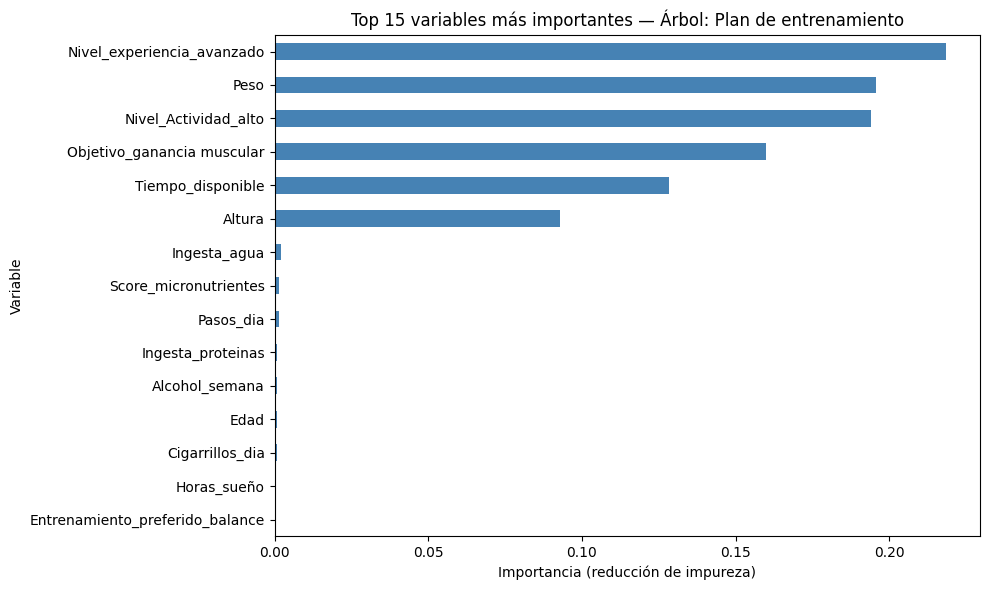


Top 10 variables más importantes:


,Importancia
Nivel_experiencia_avanzado,0.218541
Peso,0.195659
Nivel_Actividad_alto,0.194080
Objetivo_ganancia muscular,0.159719
Tiempo_disponible,0.128280
Altura,0.092732
Ingesta_agua,0.002007
Score_micronutrientes,0.001411
Pasos_dia,0.001330
Ingesta_proteinas,0.000930


In [52]:
preprocesador_fit_dt_ent = best_model_dt_ent.named_steps['preprocesamiento']
ohe_dt_ent = preprocesador_fit_dt_ent.transformers_[1][1].named_steps['onehot']
cat_names_dt_ent = ohe_dt_ent.get_feature_names_out(categoricas_features).tolist()
feature_names_dt_ent = numericas_features + cat_names_dt_ent

dt_ent_model = best_model_dt_ent.named_steps['modelo']
importancias_dt_ent = pd.Series(
    dt_ent_model.feature_importances_,
    index=feature_names_dt_ent
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importancias_dt_ent.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 variables más importantes — Árbol: Plan de entrenamiento')
ax.set_xlabel('Importancia (reducción de impureza)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

print("\nTop 10 variables más importantes:")
display(importancias_dt_ent.head(10).to_frame('Importancia'))

El análisis de importancia de variables revela una concentración notable en apenas seis predictores, que en conjunto explican más del **98% de la reducción de impureza** del árbol. Las variables restantes del top 15 tienen importancias prácticamente nulas (menores a 0.002), lo que sugiere que el modelo podría simplificarse significativamente sin pérdida de desempeño.

Las tres variables más influyentes son `Nivel_experiencia_avanzado` (0.219), `Peso` (0.196) y `Nivel_Actividad_alto` (0.194), con importancias muy similares entre sí, lo que indica que ninguna domina de forma abrumadora sino que las tres estructuran conjuntamente las particiones principales del árbol. Esto es coherente con el dominio: el nivel de experiencia y el nivel de actividad actual son indicadores directos de la capacidad física del cliente, mientras que el peso determina la carga de entrenamiento adecuada.

`Objetivo_ganancia muscular` (0.160) y `Tiempo_disponible` (0.128) completan el grupo de variables clave, reflejando que la motivación del cliente y su disponibilidad horaria son factores estructurantes en la asignación del plan. `Altura` aparece en sexta posición (0.093), probablemente como proxy de complexión física en combinación con el peso.

En contraste con la regresión logística, donde `Score_micronutrientes` y `Peso` eran las variables más influyentes, el árbol de decisión otorga mayor protagonismo a variables categóricas como `Nivel_experiencia` y `Nivel_Actividad`, lo que sugiere que estos atributos cualitativos del perfil del cliente generan particiones más puras y directas para separar los planes de entrenamiento. Variables como `Horas_sueño`, `Cigarrillos_dia`, `Edad` y `Alcohol_semana` tienen importancia nula, lo que indica que no contribuyen a discriminar entre los distintos planes de entrenamiento en este modelo.

### 10.4 Visualización del árbol — Plan de entrenamiento

Se muestra el árbol limitado a los primeros niveles para facilitar la lectura de las reglas aprendidas. Cada nodo muestra el umbral de corte, el índice de impureza Gini, el número de muestras y la clase predominante.

In [53]:
arbol_reglas_ent = export_text(
    dt_ent_model,
    feature_names=list(feature_names_dt_ent),
    max_depth=3
)
print("=== Reglas de decisión (primeros 3 niveles) — Plan de entrenamiento ===")
print(arbol_reglas_ent)

=== Reglas de decisión (primeros 3 niveles) — Plan de entrenamiento ===
|--- Nivel_Actividad_alto <= 0.50
|   |--- Nivel_experiencia_avanzado <= 0.50
|   |   |--- Tiempo_disponible <= 75.50
|   |   |   |--- Objetivo_ganancia muscular <= 0.50
|   |   |   |   |--- class: Ninguno
|   |   |   |--- Objetivo_ganancia muscular >  0.50
|   |   |   |   |--- truncated branch of depth 11
|   |   |--- Tiempo_disponible >  75.50
|   |   |   |--- Objetivo_ganancia muscular <= 0.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- Objetivo_ganancia muscular >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |--- Nivel_experiencia_avanzado >  0.50
|   |   |--- Tiempo_disponible <= 75.50
|   |   |   |--- Objetivo_ganancia muscular <= 0.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- Objetivo_ganancia muscular >  0.50
|   |   |   |   |--- class: Medio
|   |   |--- Tiempo_disponible >  75.50
|   |   |   |--- Objetivo_ganancia muscular <= 0.50
|   |   |   | 

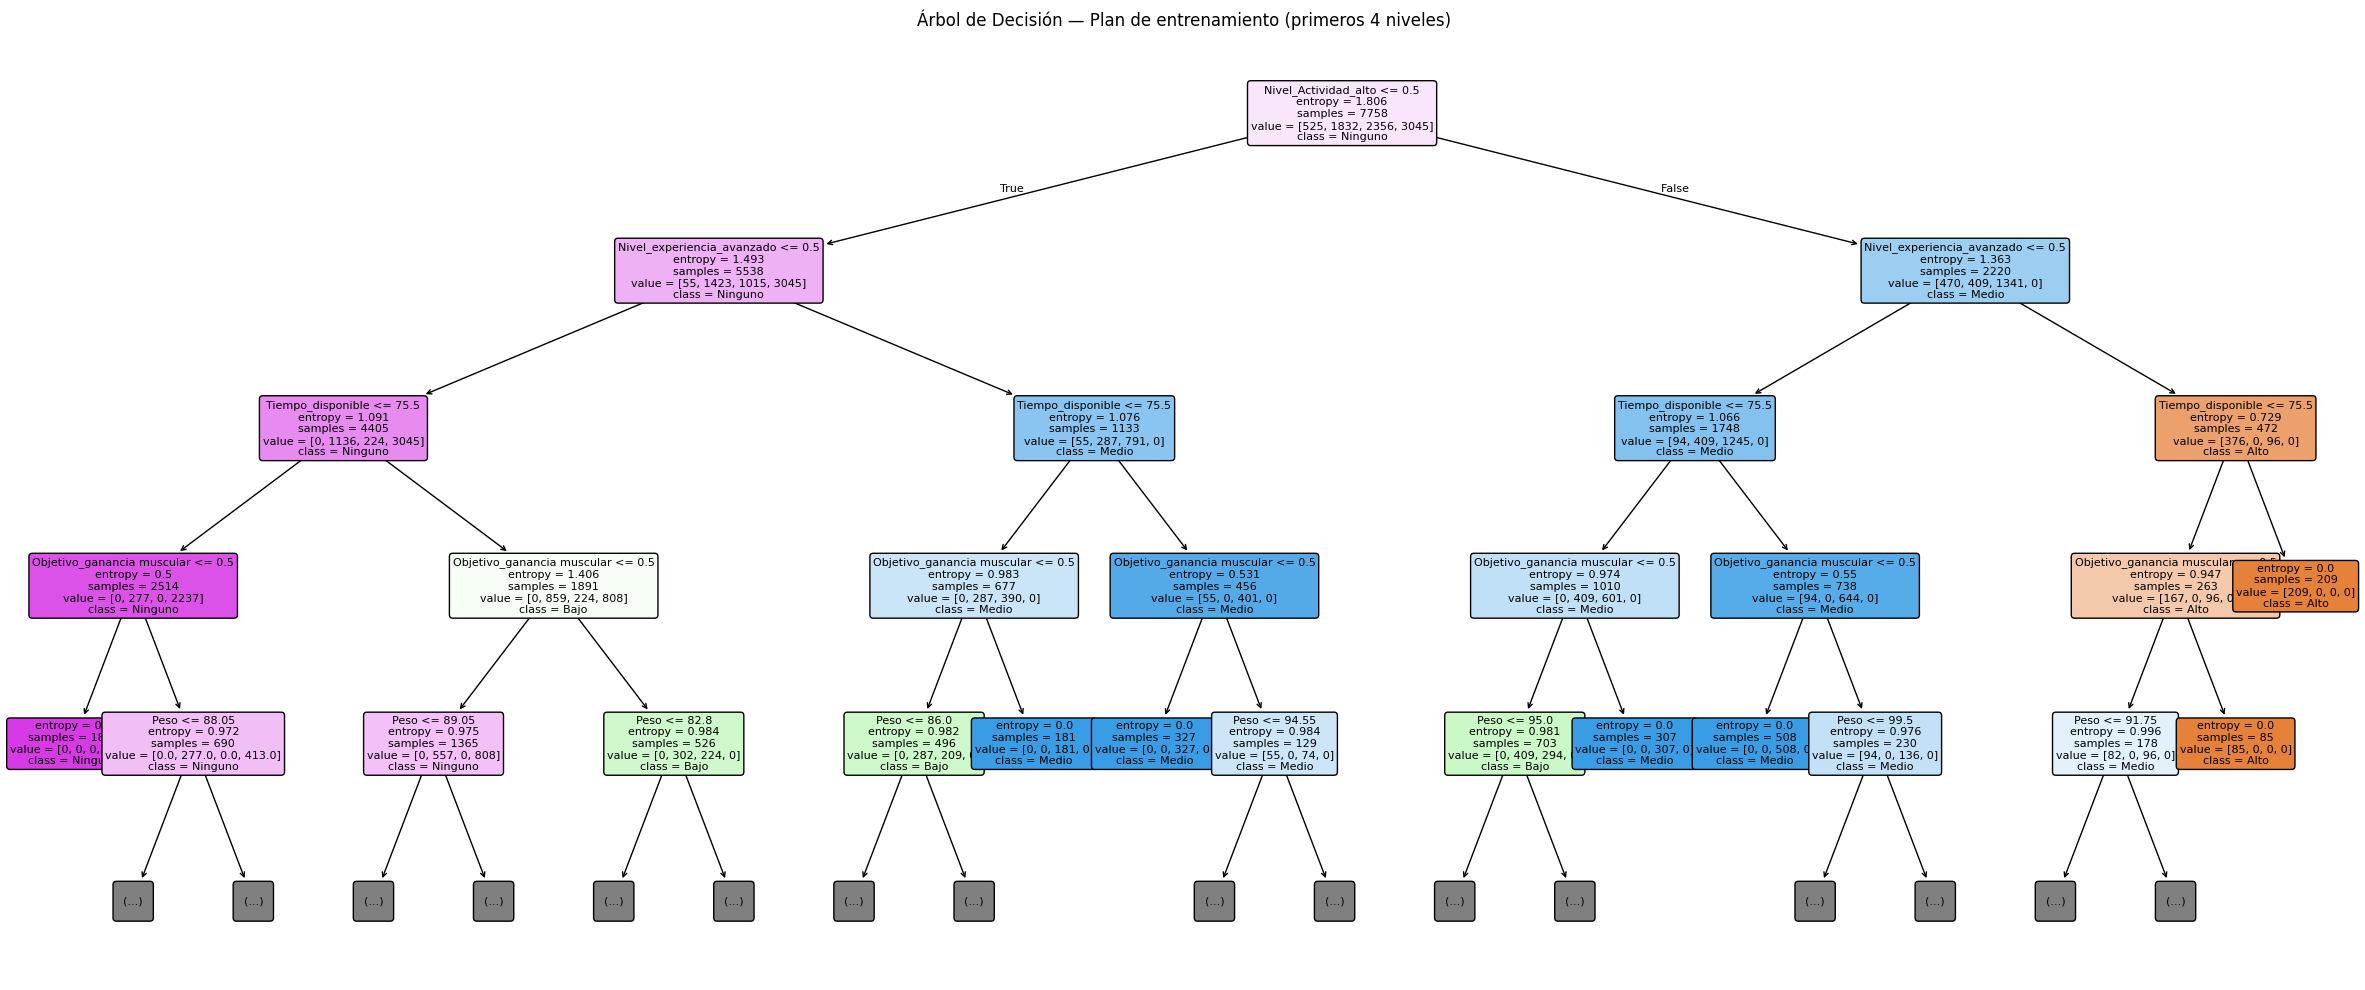

In [54]:
plt.figure(figsize=(24, 10))
plot_tree(
    dt_ent_model,
    feature_names=feature_names_dt_ent,
    class_names=dt_ent_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Árbol de Decisión — Plan de entrenamiento (primeros 4 niveles)")
plt.tight_layout()
plt.show()

La visualización del árbol y las reglas de decisión permiten interpretar explícitamente la lógica aprendida por el modelo. Las primeras particiones revelan una jerarquía clara de variables: el árbol comienza evaluando `Nivel_Actividad_alto`, lo que divide inmediatamente el espacio en dos grandes grupos de clientes. Esta variable actúa como el discriminador más global, coherente con su alta importancia medida previamente.

A partir de ahí, el segundo nivel introduce `Nivel_experiencia_avanzado`, refinando la segmentación dentro de cada rama. El tercer nivel incorpora `Tiempo_disponible` (con umbral en 75.5 horas), y el cuarto `Objetivo_ganancia muscular` y `Peso`, variables que terminan de definir la clase asignada. Esta estructura jerárquica es interpretable en términos de negocio: primero se evalúa qué tan activo es el cliente hoy, luego su experiencia acumulada, después cuánto tiempo puede dedicar al entrenamiento y finalmente su objetivo y condición física.

Las reglas más directas que emergen del árbol son:
- Si `Nivel_Actividad_alto = False` y `Nivel_experiencia_avanzado = False` y `Tiempo_disponible ≤ 75.5` y `Objetivo_ganancia muscular = False` → **Ninguno**
- Si `Nivel_Actividad_alto = True` y `Nivel_experiencia_avanzado = True` y `Tiempo_disponible > 75.5` → **Alto**
- Si `Nivel_Actividad_alto = True` y `Nivel_experiencia_avanzado = False` → derivado hacia **Medio** o **Bajo** según peso y objetivo

Estas reglas tienen una utilidad práctica clara para SmartAlpes: pueden traducirse directamente en criterios de triaje para los entrenadores, permitiendo asignar planes de forma rápida y consistente. Sin embargo, presentan también limitaciones inherentes. Al tratarse de particiones binarias y secuenciales, el árbol no captura interacciones suaves entre variables continuas, y las reglas son sensibles a pequeños cambios en los umbrales aprendidos. Adicionalmente, ramas profundas como las truncadas en el nivel 3 pueden ser difíciles de auditar, reduciendo la transparencia total del modelo a medida que aumenta la profundidad.

## 11. Modelo de Árbol de Decisión — Plan de nutrición

Se reutiliza el mismo `pipeline_dt` y `param_grid_dt` definidos anteriormente. La búsqueda se realiza sobre el conjunto de entrenamiento correspondiente a nutrición.

In [55]:
grid_dt_nut = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=skfold,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_dt_nut.fit(X_train_nut, y_train_nut)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x11136b280>)),
                                       ('limpieza_clinica',
                                        FunctionTransformer(func=<function limpieza_clinica at 0x128a42d30>)),
                                       ('normalizar_categoricas_tr',
                                        FunctionTransformer(func=<function normalizar_categoricas at 0x12...
                                                                          'Dieta_preferida',
                                                                          'Entrenamiento_preferido'])])),
                                       ('modelo',
                                        DecisionTreeClassifier(random_state=1))]),
             n_jobs=-1,
             param_grid={'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [5, 10, 15, 20, None],
                         'modelo__max_features': ['sqrt', 'log2', None],
                         'modelo__min_samples_leaf': [1, 5, 10],
                         'modelo__min_samples_split': [2, 10, 20]},
             return_train_score=True, scoring='f1_macro')

In [56]:
print("Mejores hiperparámetros — Árbol Plan nutrición:")
display(grid_dt_nut.best_params_)
print(f"\nMejor F1-macro en CV: {grid_dt_nut.best_score_:.4f}")

Mejores hiperparámetros — Árbol Plan nutrición:


{'modelo__criterion': 'gini',
 'modelo__max_depth': 15,
 'modelo__max_features': None,
 'modelo__min_samples_leaf': 5,
 'modelo__min_samples_split': 2}


Mejor F1-macro en CV: 0.9563


In [57]:
resultados_dt_nut = pd.DataFrame(grid_dt_nut.cv_results_)
summary_dt_nut = resultados_dt_nut[cols_dt].sort_values('rank_test_score').head(10)
display(summary_dt_nut)

,param_modelo__criterion,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__min_samples_leaf,param_modelo__max_features,mean_test_score,std_test_score,rank_test_score
102,gini,20,2,5,None,0.956276,0.003970,1
103,gini,20,10,5,None,0.956276,0.003970,1
75,gini,15,2,5,None,0.956276,0.003970,1
130,gini,None,10,5,None,0.956276,0.003970,1
76,gini,15,10,5,None,0.956276,0.003970,1
129,gini,None,2,5,None,0.956276,0.003970,1
48,gini,10,2,5,None,0.956189,0.003842,7
49,gini,10,10,5,None,0.956189,0.003842,7
180,entropy,10,2,1,None,0.955128,0.006934,9
261,entropy,None,2,1,None,0.954102,0.007848,10


La búsqueda de hiperparámetros para el plan de nutrición obtuvo un **F1-macro de 0.9563 en validación cruzada**, resultado inferior al 0.9701 alcanzado para el plan de entrenamiento, lo que es consistente con el patrón observado en la regresión logística donde la predicción nutricional resultó más compleja. No obstante, sigue siendo un desempeño notablemente superior al 0.7886 que obtuvo la regresión logística para este mismo objetivo, confirmando que el árbol de decisión captura mejor las relaciones que determinan el plan nutricional.

La configuración ganadora usa **criterio Gini**, **profundidad máxima de 15** y **`max_features=None`**, con `min_samples_split=2` y `min_samples_leaf=5`. A diferencia del modelo de entrenamiento que usó entropía con `min_samples_leaf=1`, aquí aparece una ligera restricción en las hojas (`min_samples_leaf=5`), lo que indica que el árbol necesita un mínimo de regularización adicional para generalizar bien en el problema nutricional.

Un aspecto llamativo del top 10 es que las primeras seis configuraciones comparten exactamente el mismo F1-macro (0.9563), variando únicamente en la profundidad (`10`, `15`, `20` y `None`) y en `min_samples_leaf` (`5` o `10`). Esto indica que a partir de cierta profundidad el modelo satura su capacidad discriminativa y profundidades adicionales no aportan mejora, sugiriendo que las reglas relevantes se aprenden en los primeros niveles del árbol. La entropía aparece recién en el noveno y décimo puesto con F1 ligeramente inferior, confirmando que Gini es el criterio más adecuado para este problema.

### 11.1 Evaluación sobre el conjunto de prueba — Plan de nutrición

In [58]:
best_model_dt_nut = grid_dt_nut.best_estimator_
y_pred_dt_nut = best_model_dt_nut.predict(X_test_nut)

print("=== Reporte de clasificación — Árbol de Decisión: Plan de nutrición ===")
print(classification_report(y_test_nut, y_pred_dt_nut))

=== Reporte de clasificación — Árbol de Decisión: Plan de nutrición ===
               precision    recall  f1-score   support

   Balanceado       0.97      0.97      0.97       860
       Basico       0.91      0.93      0.92       457
Especializado       0.97      0.96      0.96       118
     Sin plan       0.99      0.96      0.97       505

     accuracy                           0.96      1940
    macro avg       0.96      0.96      0.96      1940
 weighted avg       0.96      0.96      0.96      1940



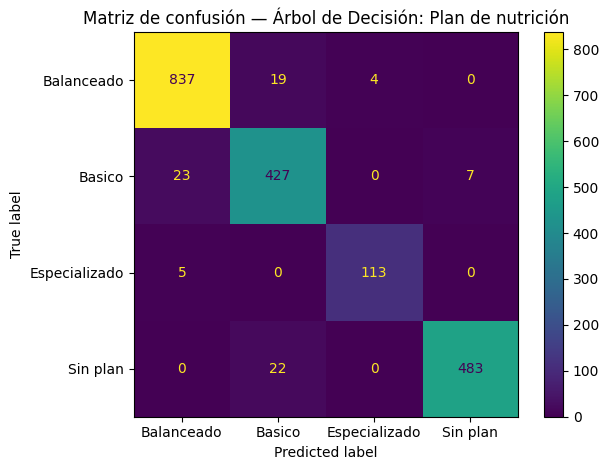

In [59]:
ConfusionMatrixDisplay.from_predictions(y_test_nut, y_pred_dt_nut)
plt.title("Matriz de confusión — Árbol de Decisión: Plan de nutrición")
plt.tight_layout()
plt.show()

El árbol de decisión para el plan de nutrición alcanza una **exactitud del 96%** sobre el conjunto de prueba, con un **F1-macro de 0.96**, superando ampliamente a la regresión logística que obtuvo 0.76 para este mismo objetivo. Esta mejora es especialmente significativa considerando que la regresión logística presentaba dificultades notables con las clases minoritarias.

A nivel de clases, el desempeño es consistentemente alto en todas las categorías. `Sin plan` obtiene la mayor precisión (0.99), seguido de `Balanceado` y `Especializado` (0.97 ambos), mientras que `Basico` presenta los valores más bajos aunque igualmente sólidos (precisión 0.91, recall 0.93, F1 0.92). Este resultado contrasta fuertemente con la regresión logística, donde `Especializado` obtenía un F1 de apenas 0.63 con un recall de 0.57. El árbol resuelve casi por completo esta debilidad, llevando `Especializado` a un F1 de 0.96.

La matriz de confusión revela que los errores son escasos y concentrados en patrones coherentes. El error más frecuente ocurre entre `Basico` y `Balanceado` (23 casos clasificados como `Balanceado` cuando eran `Basico`), seguido de `Sin plan` clasificado como `Basico` (22 casos) y `Balanceado` clasificado como `Basico` (19 casos). Estas confusiones se producen entre clases nutricionalmente adyacentes, lo que es esperable desde el dominio. Notablemente, los errores entre `Especializado` y otras clases son mínimos (solo 5 casos), lo que indica que el árbol aprendió con claridad las características que distinguen a los clientes que requieren un plan especializado, algo que la regresión logística no lograba.

### 11.2 Importancia de variables — Plan de nutrición

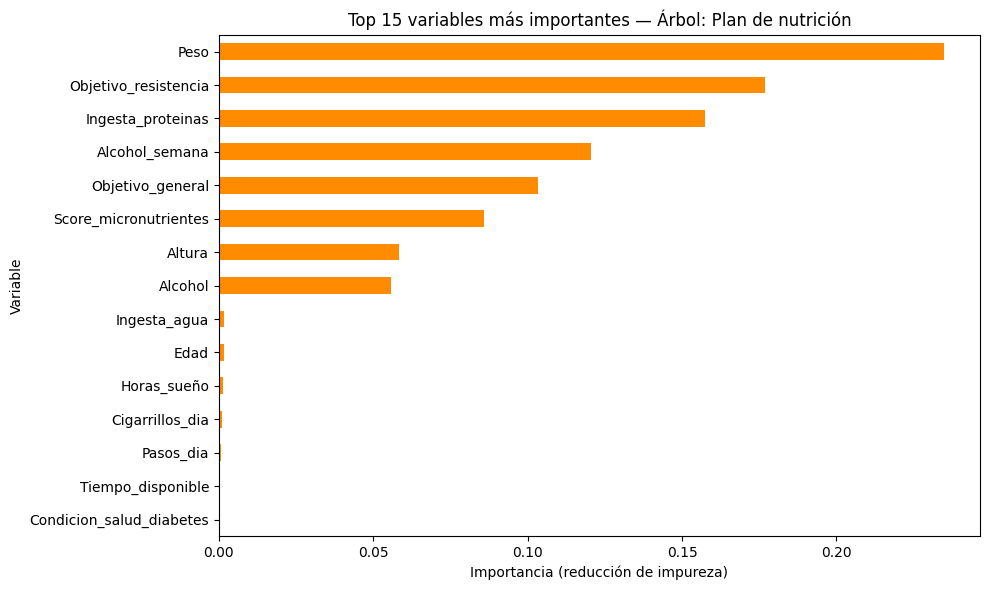


Top 10 variables más importantes:


,Importancia
Peso,0.234762
Objetivo_resistencia,0.176763
Ingesta_proteinas,0.157565
Alcohol_semana,0.120462
Objetivo_general,0.103245
Score_micronutrientes,0.085835
Altura,0.058263
Alcohol,0.055821
Ingesta_agua,0.001591
Edad,0.001556


In [60]:
preprocesador_fit_dt_nut = best_model_dt_nut.named_steps['preprocesamiento']
ohe_dt_nut = preprocesador_fit_dt_nut.transformers_[1][1].named_steps['onehot']
cat_names_dt_nut = ohe_dt_nut.get_feature_names_out(categoricas_features).tolist()
feature_names_dt_nut = numericas_features + cat_names_dt_nut

dt_nut_model = best_model_dt_nut.named_steps['modelo']
importancias_dt_nut = pd.Series(
    dt_nut_model.feature_importances_,
    index=feature_names_dt_nut
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importancias_dt_nut.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 15 variables más importantes — Árbol: Plan de nutrición')
ax.set_xlabel('Importancia (reducción de impureza)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

print("\nTop 10 variables más importantes:")
display(importancias_dt_nut.head(10).to_frame('Importancia'))

El análisis de importancia de variables para el plan de nutrición muestra un patrón diferente al observado en el plan de entrenamiento. Las primeras ocho variables concentran prácticamente toda la capacidad predictiva del modelo, con una caída abrupta a partir de `Ingesta_agua` (0.0016), mientras que variables como `Tiempo_disponible`, `Pasos_dia`, `Cigarrillos_dia` y `Condicion_salud_diabetes` tienen importancia nula o despreciable.

`Peso` encabeza el ranking con una importancia de 0.235, siendo la variable más determinante por un margen considerable. Esto es coherente con el dominio nutricional, ya que el peso corporal es el principal parámetro para calcular requerimientos calóricos y de macronutrientes. Le siguen `Objetivo_resistencia` (0.177) e `Ingesta_proteinas` (0.158), que juntos con el peso capturan el perfil metabólico y deportivo del cliente. `Alcohol_semana` (0.120) y `Objetivo_general` (0.103) completan el grupo de variables con importancia sustancial, reflejando que los hábitos de consumo y la motivación del cliente influyen en el tipo de plan nutricional asignado. `Score_micronutrientes` (0.086), `Altura` (0.058) y `Alcohol` (0.056) aportan información complementaria aunque con menor peso relativo.

Comparando con el modelo de entrenamiento, el perfil de variables relevantes es completamente distinto: mientras que allí dominaban `Nivel_experiencia`, `Nivel_Actividad` y `Tiempo_disponible`, aquí el protagonismo recae en indicadores metabólicos y nutricionales como `Peso`, `Ingesta_proteinas` y `Score_micronutrientes`. Esto valida que ambos objetivos de predicción responden a dimensiones diferentes del perfil del cliente y justifica el enfoque de entrenar modelos separados para cada uno. Respecto a la regresión logística, donde `Score_micronutrientes` y `Peso` lideraban la influencia, el árbol amplía el conjunto de variables relevantes incorporando `Objetivo_resistencia` y `Alcohol_semana` como factores estructurantes, lo que sugiere que estas variables tienen un efecto no lineal que el árbol captura con mayor precisión.

### 11.3 Visualización del árbol — Plan de nutrición

In [61]:
arbol_reglas_nut = export_text(
    dt_nut_model,
    feature_names=list(feature_names_dt_nut),
    max_depth=3
)
print("=== Reglas de decisión (primeros 3 niveles) — Plan de nutrición ===")
print(arbol_reglas_nut)

=== Reglas de decisión (primeros 3 niveles) — Plan de nutrición ===
|--- Objetivo_general <= 0.50
|   |--- Objetivo_resistencia <= 0.50
|   |   |--- Score_micronutrientes <= 0.41
|   |   |   |--- Alcohol_semana <= 1.20
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Alcohol_semana >  1.20
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- Score_micronutrientes >  0.41
|   |   |   |--- Peso <= 88.75
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- Peso >  88.75
|   |   |   |   |--- truncated branch of depth 9
|   |--- Objetivo_resistencia >  0.50
|   |   |--- Score_micronutrientes <= 0.39
|   |   |   |--- Alcohol <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Alcohol >  0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- Score_micronutrientes >  0.39
|   |   |   |--- Alcohol_semana <= 1.05
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Alcohol_semana >  1.05
|   |   |   |   |--- tr

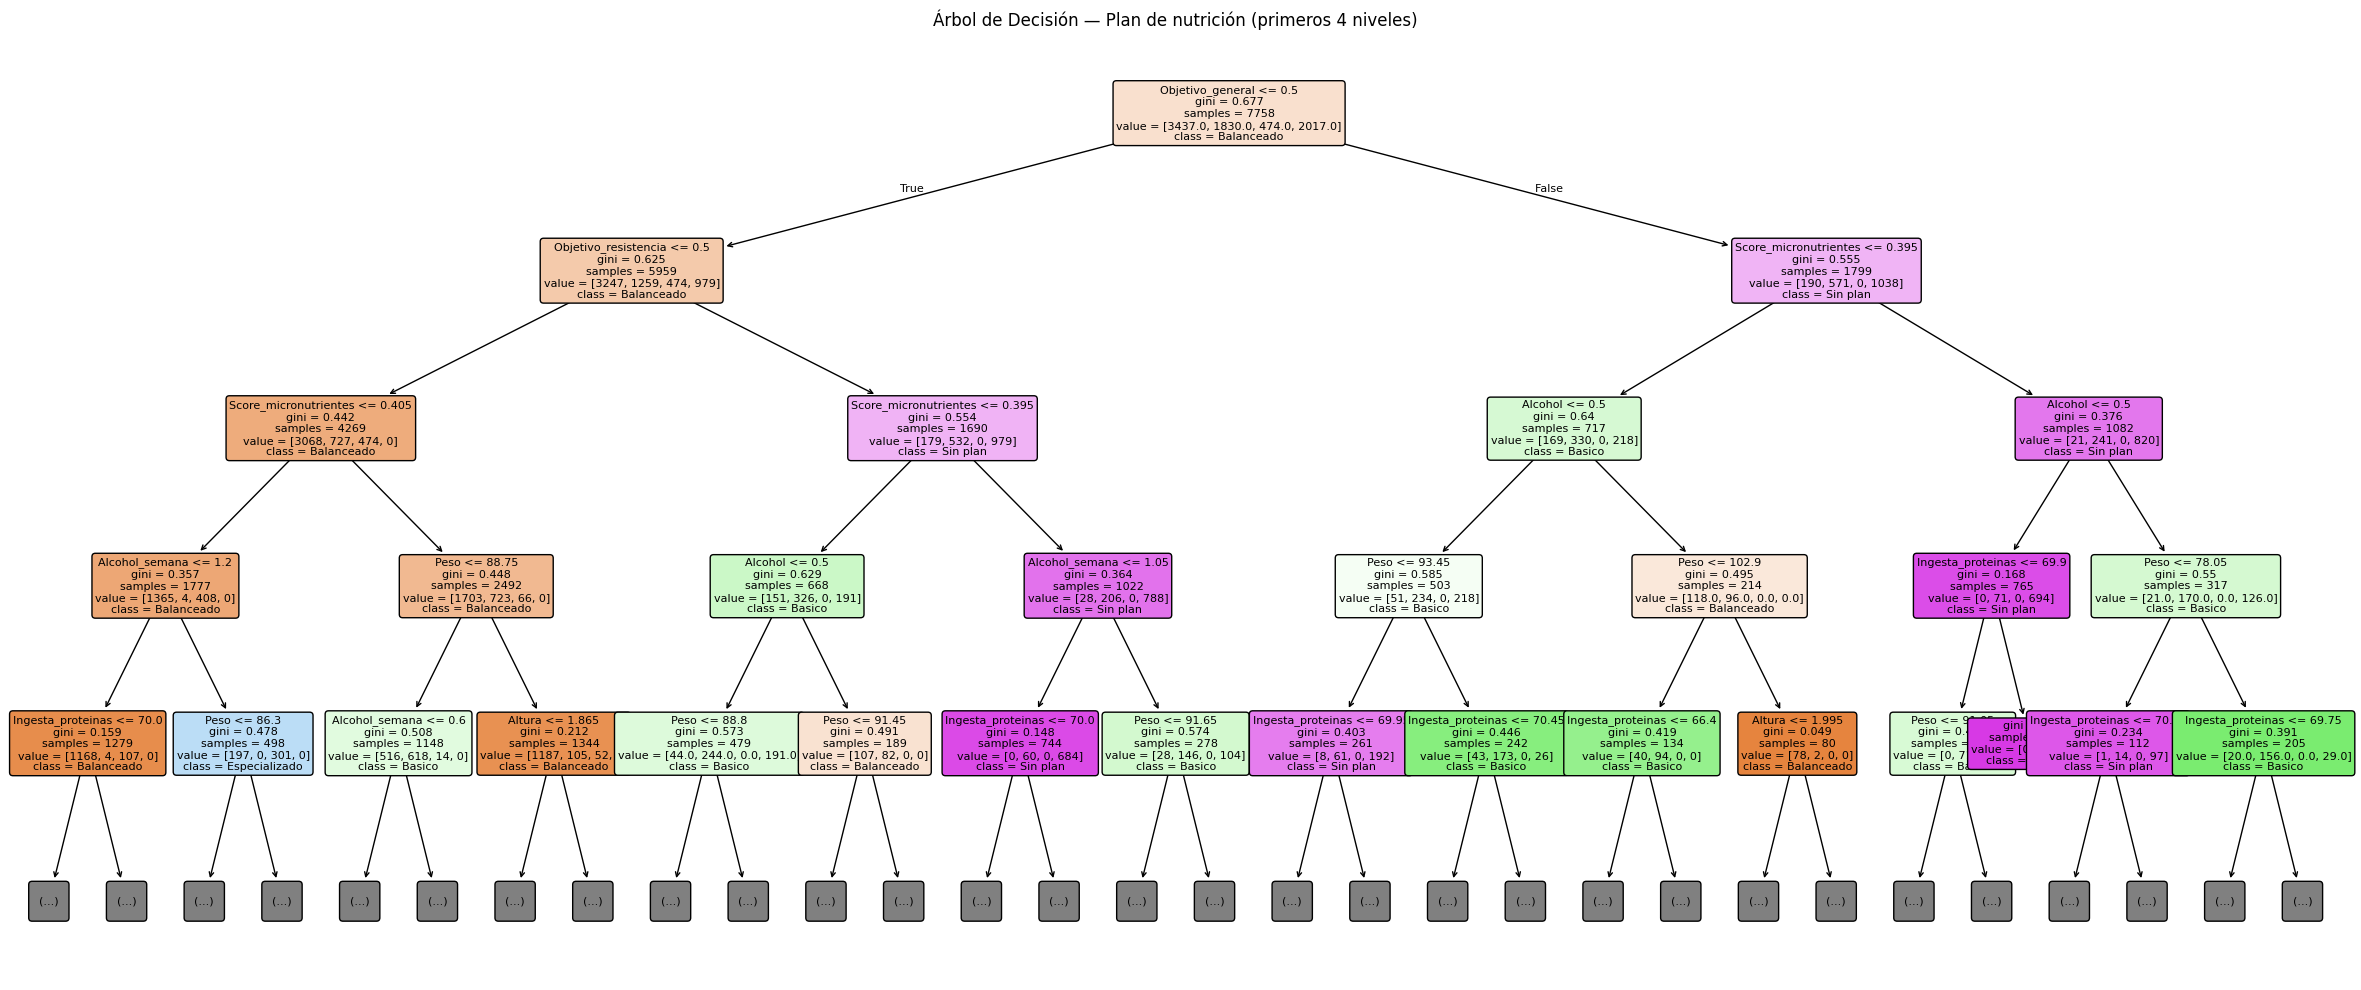

In [62]:
plt.figure(figsize=(24, 10))
plot_tree(
    dt_nut_model,
    feature_names=feature_names_dt_nut,
    class_names=dt_nut_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Árbol de Decisión — Plan de nutrición (primeros 4 niveles)")
plt.tight_layout()
plt.show()

La estructura del árbol de nutrición revela una lógica de decisión diferente a la del plan de entrenamiento. La variable raíz es `Objetivo_general`, que divide el espacio en dos grandes ramas desde el primer nivel. Esto contrasta con el árbol de entrenamiento donde la raíz era `Nivel_Actividad_alto`, y refleja que para la recomendación nutricional el punto de partida es la motivación del cliente, no su condición física actual.

En la rama izquierda (`Objetivo_general = False`), el segundo nivel introduce `Objetivo_resistencia`, y el tercero `Score_micronutrientes`, construyendo una segmentación progresiva basada en el perfil dietético y deportivo del cliente. En la rama derecha (`Objetivo_general = True`), el segundo nivel usa directamente `Score_micronutrientes`, confirmando que este indicador es central para distinguir entre planes cuando el cliente tiene un objetivo general. A partir del tercer y cuarto nivel aparecen variables como `Alcohol_semana`, `Peso`, `Altura` e `Ingesta_proteinas`, que terminan de ajustar la recomendación según hábitos de consumo y condición física.

Las reglas más interpretables que emergen del árbol son:
- Si `Objetivo_general = False` y `Objetivo_resistencia = False` y `Score_micronutrientes ≤ 0.41` y `Alcohol_semana ≤ 1.2` → tendencia a **Balanceado**
- Si `Objetivo_general = False` y `Objetivo_resistencia = True` y `Score_micronutrientes ≤ 0.39` y `Alcohol = False` → tendencia a **Básico**
- Si `Objetivo_general = True` y `Score_micronutrientes ≤ 0.395` → tendencia a **Sin plan** o **Básico** según peso
- Si `Objetivo_general = True` y `Score_micronutrientes > 0.395` y `Alcohol = False` e `Ingesta_proteinas` alta → tendencia a **Sin plan**

Comparado con el árbol de entrenamiento, este árbol es estructuralmente más complejo en los niveles intermedios: mientras que el de entrenamiento usaba las mismas cuatro variables en casi todas las ramas (`Nivel_Actividad`, `Nivel_experiencia`, `Tiempo_disponible`, `Objetivo`), el árbol de nutrición combina variables del objetivo del cliente con indicadores metabólicos y de hábitos en distintas combinaciones según la rama. Esto explica parcialmente por qué el F1-macro de nutrición (0.9563) es levemente inferior al de entrenamiento (0.9701): las fronteras de decisión son más heterogéneas y requieren mayor profundidad para resolverse correctamente.

## 12. Tabla comparativa de modelos

Se comparan los cuatro modelos entrenados sobre el conjunto de prueba usando precisión, recall y F1-score macro. Esta comparación permite seleccionar el mejor modelo para cada objetivo de predicción.

In [63]:
def metricas_modelo(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall (macro)': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1-macro': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }

tabla_ent = pd.DataFrame([
    metricas_modelo(y_test_ent, y_pred_rl_ent, 'Reg. Logística — Plan entrenamiento'),
    metricas_modelo(y_test_ent, y_pred_dt_ent, 'Árbol Decisión  — Plan entrenamiento'),
])

tabla_nut = pd.DataFrame([
    metricas_modelo(y_test_nut, y_pred_rl_nut, 'Reg. Logística — Plan nutrición'),
    metricas_modelo(y_test_nut, y_pred_dt_nut, 'Árbol Decisión  — Plan nutrición'),
])

print("=== Comparativa — Plan de entrenamiento ===")
display(tabla_ent)

print("\n=== Comparativa — Plan de nutrición ===")
display(tabla_nut)

=== Comparativa — Plan de entrenamiento ===


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-macro
0,Reg. Logística — Plan entrenamiento,0.8840,0.8848,0.8614,0.8722
1,Árbol Decisión — Plan entrenamiento,0.9794,0.9708,0.9682,0.9695



=== Comparativa — Plan de nutrición ===


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-macro
0,Reg. Logística — Plan nutrición,0.8113,0.7787,0.7496,0.7623
1,Árbol Decisión — Plan nutrición,0.9588,0.9579,0.9554,0.9566


La tabla comparativa consolida el desempeño de los cuatro modelos sobre el conjunto de prueba y permite extraer conclusiones claras sobre qué enfoque es más adecuado para cada objetivo.

**Plan de entrenamiento:** El árbol de decisión supera a la regresión logística en todas las métricas. El F1-macro pasa de 0.8722 a 0.9695, una mejora de casi 10 puntos porcentuales. La precisión macro sube de 0.8848 a 0.9708 y el recall de 0.8614 a 0.9682. Esta diferencia indica que el árbol captura relaciones no lineales entre variables como `Nivel_experiencia`, `Nivel_Actividad` y `Tiempo_disponible` que la regresión logística, al ser un modelo lineal, no logra modelar adecuadamente.

**Plan de nutrición:** La ventaja del árbol es aún más pronunciada. El F1-macro sube de 0.7623 a 0.9566, una mejora de casi 20 puntos porcentuales. La precisión macro pasa de 0.7787 a 0.9579 y el recall de 0.7496 a 0.9554. Este salto es especialmente relevante porque la regresión logística presentaba dificultades severas con la clase `Especializado` (F1 de 0.63), mientras que el árbol la resuelve con un F1 de 0.96. Esto sugiere que las reglas que determinan un plan nutricional especializado son inherentemente no lineales e involucran combinaciones específicas de variables como `Peso`, `Objetivo_resistencia` e `Ingesta_proteinas` que el árbol identifica con precisión mediante sus particiones jerárquicas.

**Selección del mejor modelo:** Para ambos objetivos, el árbol de decisión es el modelo ganador de forma clara y consistente. No se trata de una diferencia marginal que pueda atribuirse a varianza muestral: en entrenamiento la ventaja es de ~10 puntos y en nutrición de ~20 puntos en F1-macro. Adicionalmente, el árbol ofrece interpretabilidad explícita mediante reglas de decisión, lo que representa un valor agregado importante para SmartAlpes, ya que permite a los entrenadores auditar y comprender las recomendaciones generadas por el modelo. Por estas razones, el árbol de decisión será el modelo seleccionado para generar las predicciones sobre los datos de prueba no etiquetados.

## 13. Identificación y comparación de variables relevantes

### 13.1 Plan de entrenamiento

Ambos modelos coinciden en que las variables más determinantes para predecir el plan de entrenamiento son `Nivel_experiencia_avanzado`, `Nivel_Actividad_alto`, `Tiempo_disponible`, `Peso` y `Objetivo_ganancia muscular`. Sin embargo, la forma en que cada modelo utiliza estas variables difiere sustancialmente.

En la **regresión logística**, los coeficientes revelan efectos direccionales claros por clase: `Nivel_experiencia_avanzado`, `Nivel_Actividad_alto` y `Tiempo_disponible` tienen coeficientes fuertemente positivos para la clase `Alto` y fuertemente negativos para `Ninguno`, lo que indica que estas variables empujan al modelo en direcciones opuestas según la clase evaluada. `Peso` sigue el mismo patrón: coeficiente positivo para `Alto` y `Medio`, y negativo para `Bajo` y `Ninguno`. La clase `Bajo` se caracteriza por coeficientes negativos en casi todas las variables relevantes, lo que sugiere que este plan se asigna por exclusión cuando el cliente no presenta ningún atributo de alta actividad o experiencia.

En el **árbol de decisión**, las mismas variables dominan pero su importancia se mide de forma global como reducción de impureza acumulada. `Nivel_experiencia_avanzado` (0.219), `Peso` (0.196) y `Nivel_Actividad_alto` (0.194) lideran el ranking con importancias muy similares entre sí, seguidos de `Objetivo_ganancia muscular` (0.160) y `Tiempo_disponible` (0.128). A diferencia de la regresión logística, el árbol no asigna efectos direccionales por clase sino que usa estas variables como criterios de partición jerárquicos, lo que le permite capturar interacciones no lineales entre ellas. Esto explica su ventaja en desempeño: por ejemplo, la combinación específica de `Nivel_Actividad_alto = True` y `Nivel_experiencia_avanzado = True` y `Tiempo_disponible > 75.5` lleva directamente a la clase `Alto`, una interacción que la regresión logística solo puede aproximar linealmente.

`Altura` aparece con importancia moderada en el árbol (0.093) pero con coeficiente negativo en la regresión logística para casi todas las clases, sugiriendo que su efecto es no lineal y el árbol lo captura mejor. Variables como `Horas_sueño`, `Cigarrillos_dia`, `Edad` y `Alcohol_semana` tienen importancia nula en el árbol y coeficientes marginales en la regresión logística, por lo que pueden considerarse poco informativas para este objetivo.

### 13.2 Plan de nutrición

Para el plan de nutrición, ambos modelos también convergen en un conjunto central de variables relevantes, aunque con diferencias más marcadas en el peso relativo asignado a cada una.

En la **regresión logística**, `Score_micronutrientes` y `Peso` son las variables con mayor magnitud de coeficiente en prácticamente todas las clases, pero con efectos opuestos según la categoría. `Score_micronutrientes` tiene coeficiente fuertemente positivo para `Sin plan` (≈10) y para `Basico`, pero fuertemente negativo para `Especializado` (≈-10) y negativo para `Balanceado`, lo que indica que un score alto de micronutrientes aleja al cliente de planes especializados. `Peso` muestra el patrón inverso: coeficiente positivo para `Especializado` y negativo para `Sin plan`, reflejando que mayor peso corporal se asocia con necesidad de un plan más específico. El `Objetivo` del cliente también juega un papel relevante: `Objetivo_resistencia` y `Objetivo_general` tienen coeficientes negativos para `Balanceado` y positivos para `Basico` y `Sin plan`, mientras que `Objetivo_ganancia muscular` favorece `Balanceado` y `Especializado`.

En el **árbol de decisión**, `Peso` escala a la primera posición (0.235), seguido de `Objetivo_resistencia` (0.177) e `Ingesta_proteinas` (0.158), variables que en la regresión logística tenían importancia secundaria. `Alcohol_semana` (0.120) y `Objetivo_general` (0.103) también emergen como factores estructurantes, mientras que `Score_micronutrientes` baja al sexto lugar (0.086) pese a ser dominante en la regresión logística. Esta diferencia es conceptualmente relevante: la regresión logística detecta `Score_micronutrientes` como el predictor lineal más fuerte, pero el árbol revela que su efecto está condicionado por combinaciones con otras variables como `Objetivo_resistencia` y `Peso`, lo que explica por qué el árbol generaliza mejor, especialmente para la clase `Especializado`.

`Ingesta_proteinas` es la variable que más gana protagonismo al pasar de la regresión logística al árbol, sugiriendo que su efecto sobre el plan nutricional es inherentemente no lineal: no actúa de forma aditiva sino en combinación con el peso y el objetivo del cliente. En contraste, variables como `Tiempo_disponible`, `Pasos_dia`, `Horas_sueño` y `Cigarrillos_dia` tienen importancia nula en el árbol y coeficientes marginales en la regresión logística, confirmando que no aportan información discriminativa para la recomendación nutricional.

### 13.3 Síntesis comparativa

Ambos modelos y ambos objetivos comparten un hallazgo central: **la recomendación de planes en SmartAlpes está determinada por un subconjunto reducido de variables**, con la mayoría de los predictores siendo prácticamente irrelevantes. Para el entrenamiento, ese núcleo está compuesto por variables de capacidad y experiencia física (`Nivel_experiencia`, `Nivel_Actividad`, `Tiempo_disponible`, `Peso`), mientras que para la nutrición el núcleo combina indicadores metabólicos y de hábitos (`Peso`, `Ingesta_proteinas`, `Score_micronutrientes`, `Alcohol_semana`) con el objetivo declarado del cliente.

La principal diferencia entre modelos radica en que la regresión logística captura efectos lineales y direccionales por clase, siendo útil para entender en qué sentido cada variable empuja la predicción, mientras que el árbol de decisión captura interacciones y umbrales específicos que permiten un desempeño superior. Ambas perspectivas son complementarias: la regresión logística es más adecuada para explicar el efecto individual de cada variable, y el árbol para entender las combinaciones de condiciones que determinan cada recomendación.

## 14. Análisis de resultados

### ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?

Para el **plan de entrenamiento**, las características más relacionadas son `Nivel_experiencia_avanzado`, `Nivel_Actividad_alto`, `Tiempo_disponible`, `Peso` y `Objetivo_ganancia muscular`. Estas variables reflejan la capacidad física actual del cliente, su historial deportivo y su disponibilidad, que son los factores más lógicos para determinar la intensidad del plan. Para el **plan de nutrición**, las variables más relevantes son `Peso`, `Objetivo_resistencia`, `Ingesta_proteinas`, `Alcohol_semana`, `Objetivo_general` y `Score_micronutrientes`. En este caso el perfil metabólico, los hábitos alimenticios y el objetivo declarado del cliente son los principales determinantes. En ambos casos, ambos modelos coinciden en que un subconjunto reducido de variables concentra prácticamente toda la capacidad predictiva, lo que sugiere que las reglas de recomendación en SmartAlpes responden a criterios claros y consistentes.

### ¿Existen variables que podrían ser redundantes o poco informativas?

Sí. En el árbol de decisión para entrenamiento, variables como `Horas_sueño`, `Cigarrillos_dia`, `Edad`, `Alcohol_semana`, `Ingesta_proteinas` y `Pasos_dia` presentan importancia prácticamente nula (menor a 0.001), lo que indica que no contribuyen a discriminar entre los distintos planes. Para nutrición, `Tiempo_disponible`, `Pasos_dia`, `Cigarrillos_dia` y `Condicion_salud_diabetes` tienen importancia nula. La regresión logística confirma este patrón con coeficientes marginales para las mismas variables. Esto sugiere que el dataset podría simplificarse sin pérdida de desempeño, reduciendo la dimensionalidad del problema y facilitando la recolección de datos en producción, ya que no sería necesario capturar todas las variables actuales para generar una recomendación confiable.

### ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

Sí, especialmente el árbol de decisión. Para el plan de entrenamiento, el árbol alcanza un F1-macro de 0.97 y una exactitud del 98% sobre el conjunto de prueba, lo que indica que reproduce con alta fidelidad las recomendaciones del dataset. Para el plan de nutrición, el F1-macro es de 0.96 con una exactitud del 96%, resultado igualmente sólido. La regresión logística también reproduce razonablemente las recomendaciones de entrenamiento (F1-macro 0.87), aunque presenta dificultades en nutrición (F1-macro 0.76), particularmente con la clase `Especializado`. En conjunto, el árbol de decisión logra capturar de forma casi completa la lógica subyacente en las recomendaciones, lo que valida tanto la calidad del dataset como la adecuación del enfoque metodológico.

### A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas las características que cumplen las variables involucradas en la recomendación que se da. Incluya además la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.

Tomando el árbol de decisión para el **plan de entrenamiento**, las reglas más representativas de los primeros niveles son:

- Si `Nivel_Actividad_alto = False` y `Nivel_experiencia_avanzado = False` y `Tiempo_disponible ≤ 75.5` y `Objetivo_ganancia muscular = False` → **Ninguno**
- Si `Nivel_Actividad_alto = False` y `Nivel_experiencia_avanzado = True` y `Tiempo_disponible > 75.5` y `Objetivo_ganancia muscular = False` → **Medio**
- Si `Nivel_Actividad_alto = True` y `Nivel_experiencia_avanzado = True` y `Tiempo_disponible > 75.5` → **Alto**
- Si `Nivel_Actividad_alto = True` y `Nivel_experiencia_avanzado = False` y `Peso ≤ 95` → **Medio** o **Bajo** según objetivo

La **utilidad** de estas reglas es significativa en el contexto de SmartAlpes. Al expresarse como condiciones lógicas sobre variables observables, pueden traducirse directamente en criterios operativos para los entrenadores, permitiendo asignar planes de forma rápida, consistente y auditable sin necesidad de conocer los detalles técnicos del modelo. Además, facilitan la detección de casos atípicos: si una recomendación no sigue la regla esperada, es posible rastrear exactamente qué variable la desvió.

Las **limitaciones** son igualmente relevantes. En primer lugar, las reglas son sensibles a pequeños cambios en los umbrales aprendidos: un cliente con `Tiempo_disponible = 76` y otro con `Tiempo_disponible = 75` pueden recibir planes distintos aunque su perfil sea prácticamente idéntico. En segundo lugar, a medida que aumenta la profundidad del árbol, las ramas se vuelven más específicas y difíciles de interpretar, reduciendo la transparencia global del modelo. En tercer lugar, las reglas aprendidas reflejan los patrones del conjunto de entrenamiento y pueden no generalizarse bien a perfiles de clientes que no estaban representados en los datos originales, lo que limita su aplicabilidad en contextos donde la distribución de usuarios cambia con el tiempo.

### ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

El modelo podría integrarse como un motor de recomendación dentro de la aplicación móvil o web de SmartAlpes. Durante el proceso de registro o actualización de perfil, el usuario completaría un formulario con las variables relevantes identificadas (nivel de actividad, experiencia, objetivo, peso, ingesta de proteínas, entre otras), y el modelo generaría automáticamente una recomendación de plan de entrenamiento y nutrición en tiempo real. El pipeline entrenado, que incluye preprocesamiento y modelo en un único objeto, puede exportarse con `joblib` y desplegarse en un servicio backend mediante una API REST, de modo que la aplicación consulte la predicción sin exponer la lógica interna del modelo. Adicionalmente, las reglas del árbol de decisión pueden mostrarse al usuario como una explicación personalizada de por qué recibió ese plan, aumentando la confianza y la adherencia al programa. El sistema podría también actualizarse periódicamente con nuevos datos de clientes para mantener la vigencia de las recomendaciones.

### ¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?

La principal limitación es que el modelo aprende patrones estadísticos a partir de datos históricos, lo que implica que sus recomendaciones reproducen las decisiones pasadas de los entrenadores, incluyendo posibles sesgos o inconsistencias. Si en el pasado ciertos perfiles de clientes recibieron planes inadecuados, el modelo los replicará. Además, el modelo no tiene capacidad de capturar información cualitativa relevante que un entrenador sí puede observar, como el estado emocional del cliente, lesiones recientes no registradas, o la motivación real en un momento específico. Otra limitación importante es la rigidez de las particiones: el modelo asigna la misma recomendación a todos los clientes que caen en una misma hoja del árbol, sin considerar matices individuales. Finalmente, el sistema requiere que el usuario reporte sus datos con honestidad y precisión; valores incorrectos en variables como `Ingesta_proteinas` o `Nivel_Actividad` pueden derivar en recomendaciones inadecuadas. Por estas razones, el modelo debe concebirse como una herramienta de apoyo a la decisión del entrenador, no como un sustituto de su criterio profesional.

### ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

Pueden identificarse varias fuentes de sesgo. En primer lugar, **sesgo de representación**: si el dataset fue recopilado principalmente de un tipo de cliente (por ejemplo, adultos jóvenes con objetivos de ganancia muscular), el modelo puede tener un desempeño inferior para perfiles subrepresentados como adultos mayores, clientes con condiciones de salud crónicas o personas con objetivos de rehabilitación. Esto se evidencia parcialmente en el menor desempeño del modelo de nutrición para la clase `Especializado` en la regresión logística, que es la clase menos frecuente. En segundo lugar, **sesgo de etiquetado**: las recomendaciones en el dataset fueron asignadas por entrenadores humanos, quienes pueden haber aplicado criterios inconsistentes o influenciados por factores no registrados. El modelo aprende estas inconsistencias como si fueran patrones válidos. En tercer lugar, **sesgo de variables proxy**: variables como `Peso` y `Altura` pueden actuar como proxies de características demográficas como género o etnia, introduciendo inequidades en las recomendaciones si esas correlaciones están presentes en los datos. Finalmente, existe un **sesgo de retroalimentación**: si el modelo se despliega y sus recomendaciones alimentan futuros datos de entrenamiento, los errores actuales se amplificarán con el tiempo, reduciendo la diversidad de planes recomendados y consolidando patrones potencialmente inadecuados.

## 15. Predicciones sobre datos de prueba no etiquetados

En esta sección se generan las predicciones sobre el conjunto de datos de prueba no etiquetado utilizando el mejor modelo identificado en la comparativa: el **árbol de decisión**, tanto para `Plan_entrenamiento` como para `Plan_nutrición`. El pipeline incluye todas las etapas de preprocesamiento, por lo que se aplica directamente sobre los datos crudos.

In [65]:
datos_test = pd.read_csv('./data/Datos test Lab3.csv', sep=';', encoding='latin-1')
print(f"Registros en datos de prueba: {datos_test.shape[0]}")
datos_test.head()

Registros en datos de prueba: 302


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.57,185.7,9384,2.18,NaN,NaN
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,0,0.0,1,23.7,0.21,182.1,10070,3.32,NaN,NaN


In [66]:
# Limpiar prefijos __ que pueden venir en algunas columnas
datos_test.columns = datos_test.columns.str.strip().str.replace('^__+', '', regex=True)

# Verificar que las columnas coincidan con el dataset de entrenamiento
cols_pred = [c for c in datos_test.columns if c not in ['Plan_entrenamiento', 'Plan_nutrición']]
X_test_final = datos_test[cols_pred]
print(f"Columnas usadas para predicción: {X_test_final.shape[1]}")
print(X_test_final.columns.tolist())

Columnas usadas para predicción: 24
['Edad', 'Gnereo', 'Peso', 'Altura', 'BMI', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Horas_sueño', 'Entrenamiento_preferido', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']


In [67]:
# Predicciones con el mejor modelo (árbol de decisión)
pred_entrenamiento = best_model_dt_ent.predict(X_test_final)
pred_nutricion = best_model_dt_nut.predict(X_test_final)

print(f"Predicciones generadas: {len(pred_entrenamiento)}")
print("\nDistribución Plan_entrenamiento:")
print(pd.Series(pred_entrenamiento).value_counts())
print("\nDistribución Plan_nutrición:")
print(pd.Series(pred_nutricion).value_counts())

Predicciones generadas: 302

Distribución Plan_entrenamiento:
Ninguno    123
Medio       88
Bajo        76
Alto        15
Name: count, dtype: int64

Distribución Plan_nutrición:
Balanceado       131
Sin plan          83
Basico            73
Especializado     15
Name: count, dtype: int64


In [68]:
# Agregar predicciones al dataframe original
resultado = datos_test.copy()
resultado['Plan_entrenamiento'] = pred_entrenamiento
resultado['Plan_nutrición'] = pred_nutricion

# Exportar
resultado.to_csv('./data/Datos_Test_Lab3_predicciones.csv', sep=';', 
                 index=False, encoding='latin-1')

print("Archivo exportado exitosamente.")
resultado[['Plan_entrenamiento', 'Plan_nutrición']].head(10)

Archivo exportado exitosamente.


,Plan_entrenamiento,Plan_nutrición
0,Medio,Balanceado
1,Medio,Sin plan
2,Medio,Basico
3,Bajo,Sin plan
4,Bajo,Balanceado
5,Medio,Balanceado
6,Bajo,Balanceado
7,Medio,Balanceado
8,Ninguno,Sin plan
9,Ninguno,Sin plan


## 16. Uso de herramientas de IA generativa

Durante el desarrollo de este laboratorio se utilizó **Claude (Anthropic)** como herramienta de apoyo para las siguientes tareas:

- Generación y estructuración del código Python para los pipelines de árboles de decisión
- Redacción e interpretación de los análisis de resultados de cada modelo
- Comparación de variables relevantes entre regresión logística y árbol de decisión
- Respuesta a las preguntas del análisis de resultados del enunciado
- Generación del código para las predicciones sobre el conjunto de prueba no etiquetado

Los prompts utilizados consistieron principalmente en proporcionar los resultados reales obtenidos al ejecutar cada sección del notebook y solicitar el análisis correspondiente, garantizando que las interpretaciones reflejaran los valores reales y no suposiciones previas.

En todos los casos, la ejecución del código, la validación de los resultados y las decisiones metodológicas clave (uso de `StratifiedKFold`, eliminación del escalado en el pipeline de árboles, selección del mejor modelo) fueron realizadas por el estudiante. La IA actuó como herramienta de apoyo y no como reemplazo del proceso de aprendizaje.

## 17. Conclusiones

El laboratorio permitió evidenciar que los árboles de decisión superan a la regresión logística en ambos objetivos de predicción para SmartAlpes. Para el plan de entrenamiento, el árbol alcanzó un F1-macro de 0.97 frente al 0.87 de la regresión logística, mientras que para el plan de nutrición la diferencia fue aún más pronunciada (0.96 vs 0.76), especialmente en la clase `Especializado` donde la regresión logística presentaba dificultades severas.

La búsqueda de hiperparámetros con validación cruzada estratificada confirmó que ambos problemas responden a un subconjunto reducido de variables: el plan de entrenamiento está determinado principalmente por `Nivel_experiencia`, `Nivel_Actividad`, `Tiempo_disponible` y `Peso`, mientras que el plan de nutrición depende de `Peso`, `Objetivo_resistencia`, `Ingesta_proteinas` y `Score_micronutrientes`. Este hallazgo sugiere que el sistema de recomendación podría simplificarse sin pérdida relevante de desempeño.

Finalmente, el laboratorio reforzó que la selección del mejor modelo debe considerar no solo la métrica de desempeño sino también la interpretabilidad: las reglas explícitas del árbol de decisión representan un valor agregado concreto para SmartAlpes, ya que permiten a los entrenadores auditar, comprender y comunicar las recomendaciones generadas, facilitando su integración en un entorno profesional real.